
# Préparation et nettoyage des données

## Importation des packages

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

## Importation des données

In [3]:
df_PIB_par_habitant = pd.read_excel("PIB_par_habitant.xlsx")
df_Emission_prod = pd.read_excel("Emission_prod.xlsx")
df_croissance_pib = pd.read_excel("croissance_pib.xlsx")
df_taux_droits_douane = pd.read_excel("taux_droits_douane.xlsx")
df_DispoAlimentaire = pd.read_excel("DisponibiliteAlimentaire_2022.xlsx")
df_productivite = pd.read_excel("productivité.xlsx")
df_Population_2022 = pd.read_excel("Population_2022.xlsx")
df_IPL = pd.read_excel("Indice_performance_Logistique.xlsx")
df_prix_prod = pd.read_excel("prix_prod.xlsx")
df_inflation_prixconso = pd.read_excel("inflation_prixconso.xlsx")
df_pays = pd.read_excel("pays.xlsx")
df_pop_serie_temp = pd.read_excel("pop_serie_temp.xlsx")

# Analyse series temporelles du pib, inflation et disponibilité alimentaire

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration du style
sns.set_style("white")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

# --- 1. CHARGEMENT ET RÉFÉRENTIEL ---
print("Chargement des données...")

# Référentiel pays
pays_ref = pd.read_csv('pays.csv', header=None, names=['ID', 'M49', 'ISO2', 'ISO3', 'Nom_FR', 'Nom_EN'])
pays_ref['ISO3'] = pays_ref['ISO3'].str.strip()
mapping_m49_iso = dict(zip(pays_ref['M49'].astype(str), pays_ref['ISO3']))

def load_wb(file, name):
    """Charge et transforme les données de la Banque Mondiale"""
    try:
        df = pd.read_csv(file, skiprows=4)
        df_l = df.melt(id_vars=['Country Code'], var_name='Année', value_name=name)
        df_l = df_l.rename(columns={'Country Code': 'ISO3'})
        df_l['Année'] = pd.to_numeric(df_l['Année'], errors='coerce')
        df_l[name] = pd.to_numeric(df_l[name], errors='coerce')
        df_l = df_l.dropna(subset=['Année', name])
        print(f"  ✓ {name}: {len(df_l)} observations chargées")
        return df_l
    except Exception as e:
        print(f"  ✗ Erreur chargement {file}: {e}")
        return pd.DataFrame()

# Données Banque Mondiale
pib = load_wb('PIB_par_habitant.csv', 'PIB')
inf = load_wb('inflation_prixalaconso.csv', 'Inflation')

# Données FAO
try:
    fao = pd.read_csv('FAOSTAT_data_fr_12-29-2025.csv')
    fao['ISO3'] = fao['Code zone (M49)'].astype(str).map(mapping_m49_iso)
    fao['Valeur'] = pd.to_numeric(fao['Valeur'], errors='coerce')
    fao_agg = fao.groupby(['ISO3', 'Année'])['Valeur'].sum().reset_index().rename(columns={'Valeur': 'Kcal'})
    print(f"  ✓ FAO: {len(fao_agg)} observations chargées")
except Exception as e:
    print(f"  ✗ Erreur chargement FAO: {e}")
    fao_agg = pd.DataFrame()

# Fusion totale
df_total = pd.merge(pd.merge(pib, inf, on=['ISO3', 'Année'], how='inner'), 
                    fao_agg, on=['ISO3', 'Année'], how='inner')
print(f"\n✓ Fusion complète: {len(df_total)} observations pour {df_total['ISO3'].nunique()} pays")

# --- 2. PRÉPARATION DES DONNÉES POUR LES 3 PAYS ---
pays_cibles = {
    "FRA": "France", 
    "USA": "États-Unis", 
    "ARE": "Émirats Arabes Unis"
}

# Filtrer les données pour les 3 pays (2010-2022)
df_compare = df_total[
    (df_total['ISO3'].isin(pays_cibles.keys())) & 
    (df_total['Année'] >= 2010) & 
    (df_total['Année'] <= 2022)
].copy()

df_compare['Pays'] = df_compare['ISO3'].map(pays_cibles)

print(f"\nDonnées disponibles pour comparaison:")
for iso, nom in pays_cibles.items():
    n = len(df_compare[df_compare['ISO3'] == iso])
    print(f"  • {nom}: {n} années")

# --- 3. GÉNÉRATION DES 3 GRAPHIQUES COMPARATIFS ---
print("\nGénération des graphiques comparatifs...\n")

# Palette de couleurs distinctes pour chaque pays
couleurs = {
    "France": "#0055A4",
    "États-Unis": "#B22234",
    "Émirats Arabes Unis": "#00732F"
}

# GRAPHIQUE 1 : PIB par habitant
fig1, ax1 = plt.subplots(figsize=(14, 7))
fig1.suptitle("Comparaison du PIB par habitant (2010-2022)", 
              fontsize=16, fontweight='bold', y=0.98)

for pays in df_compare['Pays'].unique():
    data = df_compare[df_compare['Pays'] == pays].sort_values('Année')
    ax1.plot(data['Année'], data['PIB'], 
             marker='o', markersize=7, linewidth=2.5, 
             label=pays, color=couleurs[pays], alpha=0.85)

ax1.set_xlabel('Année', fontsize=12, fontweight='bold')
ax1.set_ylabel('PIB par habitant ($ US)', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=11, frameon=True, shadow=True)
ax1.grid(False)

# Annotation 2022 pour chaque pays
for pays in df_compare['Pays'].unique():
    data_2022 = df_compare[(df_compare['Pays'] == pays) & (df_compare['Année'] == 2022)]
    if not data_2022.empty:
        val = data_2022['PIB'].values[0]
        ax1.scatter(2022, val, s=150, color=couleurs[pays], zorder=5, edgecolor='white', linewidth=2)
        ax1.annotate(f'{val:.0f}$', 
                    xy=(2022, val), xytext=(10, 0), 
                    textcoords='offset points', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.4', facecolor=couleurs[pays], alpha=0.3))

plt.tight_layout()
plt.show()

# GRAPHIQUE 2 : Inflation
fig2, ax2 = plt.subplots(figsize=(14, 7))
fig2.suptitle("Comparaison de l'Inflation (2010-2022)", 
              fontsize=16, fontweight='bold', y=0.98)

for pays in df_compare['Pays'].unique():
    data = df_compare[df_compare['Pays'] == pays].sort_values('Année')
    ax2.plot(data['Année'], data['Inflation'], 
             marker='s', markersize=7, linewidth=2.5, 
             label=pays, color=couleurs[pays], alpha=0.85)

ax2.set_xlabel('Année', fontsize=12, fontweight='bold')
ax2.set_ylabel('Inflation (% annuel)', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=11, frameon=True, shadow=True)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.grid(False)

# Annotation spéciale 2022 avec pourcentage exact
for pays in df_compare['Pays'].unique():
    data_2022 = df_compare[(df_compare['Pays'] == pays) & (df_compare['Année'] == 2022)]
    if not data_2022.empty:
        val = data_2022['Inflation'].values[0]
        ax2.scatter(2022, val, s=200, color=couleurs[pays], zorder=5, edgecolor='white', linewidth=2)
        ax2.annotate(f'{val:.1f}%', 
                    xy=(2022, val), xytext=(15, 15), 
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor=couleurs[pays], alpha=0.4, edgecolor=couleurs[pays], linewidth=2),
                    arrowprops=dict(arrowstyle='->', color=couleurs[pays], lw=2))

plt.tight_layout()
plt.show()

# GRAPHIQUE 3 : Disponibilité calorique
fig3, ax3 = plt.subplots(figsize=(14, 7))
fig3.suptitle("Comparaison de la Disponibilité Calorique (2010-2022)", 
              fontsize=16, fontweight='bold', y=0.98)

for pays in df_compare['Pays'].unique():
    data = df_compare[df_compare['Pays'] == pays].sort_values('Année')
    ax3.plot(data['Année'], data['Kcal'], 
             marker='^', markersize=7, linewidth=2.5, 
             label=pays, color=couleurs[pays], alpha=0.85)

ax3.set_xlabel('Année', fontsize=12, fontweight='bold')
ax3.set_ylabel('Disponibilité calorique (Kcal/jour/personne)', fontsize=12, fontweight='bold')
ax3.legend(loc='best', fontsize=11, frameon=True, shadow=True)
ax3.grid(False)

# Annotation 2022
for pays in df_compare['Pays'].unique():
    data_2022 = df_compare[(df_compare['Pays'] == pays) & (df_compare['Année'] == 2022)]
    if not data_2022.empty:
        val = data_2022['Kcal'].values[0]
        ax3.scatter(2022, val, s=150, color=couleurs[pays], zorder=5, edgecolor='white', linewidth=2)
        ax3.annotate(f'{val:.0f}', 
                    xy=(2022, val), xytext=(10, 0), 
                    textcoords='offset points', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.4', facecolor=couleurs[pays], alpha=0.3))

plt.tight_layout()
plt.show()

print("✓ Graphiques comparatifs générés!")

# --- 4. ANALYSE DES RELATIONS : INFLATION vs DISPONIBILITÉ ALIMENTAIRE ---
print("\nGénération des analyses de corrélation...\n")

from scipy import stats

# GRAPHIQUE 4 : Scatter plots - Inflation vs Disponibilité calorique
fig4, axes = plt.subplots(1, 3, figsize=(18, 5))
fig4.suptitle("Relation entre Inflation et Disponibilité Calorique par Pays", 
              fontsize=16, fontweight='bold', y=1.02)

for idx, (iso, nom) in enumerate(pays_cibles.items()):
    data_pays = df_compare[df_compare['ISO3'] == iso].copy()
    
    if len(data_pays) > 2:
        ax = axes[idx]
        
        # Scatter plot
        scatter = ax.scatter(data_pays['Inflation'], data_pays['Kcal'], 
                            c=data_pays['Année'], cmap='viridis', 
                            s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
        
        # Ligne de régression
        if len(data_pays) > 3:
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                data_pays['Inflation'].dropna(), 
                data_pays['Kcal'].dropna()
            )
            line_x = data_pays['Inflation']
            line_y = slope * line_x + intercept
            ax.plot(line_x, line_y, 'r--', linewidth=2, alpha=0.8, 
                   label=f'R²={r_value**2:.3f}')
            
            # Affichage de la corrélation
            ax.text(0.05, 0.95, f'Corrélation: {r_value:.3f}\np-value: {p_value:.3f}',
                   transform=ax.transAxes, fontsize=10,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_xlabel('Inflation (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Disponibilité (Kcal/j)', fontsize=11, fontweight='bold')
        ax.set_title(nom, fontsize=12, fontweight='bold', color=couleurs[nom])
        ax.legend(loc='lower right')
        ax.grid(False)
        
        # Colorbar pour les années
        if idx == 2:
            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label('Année', fontsize=10)

plt.tight_layout()
plt.show()

# GRAPHIQUE 5 : Scatter plots - PIB vs Disponibilité calorique
fig5, axes = plt.subplots(1, 3, figsize=(18, 5))
fig5.suptitle("Relation entre PIB et Disponibilité Calorique par Pays", 
              fontsize=16, fontweight='bold', y=1.02)

for idx, (iso, nom) in enumerate(pays_cibles.items()):
    data_pays = df_compare[df_compare['ISO3'] == iso].copy()
    
    if len(data_pays) > 2:
        ax = axes[idx]
        
        # Scatter plot
        scatter = ax.scatter(data_pays['PIB'], data_pays['Kcal'], 
                            c=data_pays['Année'], cmap='plasma', 
                            s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
        
        # Ligne de régression
        if len(data_pays) > 3:
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                data_pays['PIB'].dropna(), 
                data_pays['Kcal'].dropna()
            )
            line_x = data_pays['PIB']
            line_y = slope * line_x + intercept
            ax.plot(line_x, line_y, 'r--', linewidth=2, alpha=0.8, 
                   label=f'R²={r_value**2:.3f}')
            
            # Affichage de la corrélation
            ax.text(0.05, 0.95, f'Corrélation: {r_value:.3f}\np-value: {p_value:.3f}',
                   transform=ax.transAxes, fontsize=10,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        
        ax.set_xlabel('PIB par habitant ($)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Disponibilité (Kcal/j)', fontsize=11, fontweight='bold')
        ax.set_title(nom, fontsize=12, fontweight='bold', color=couleurs[nom])
        ax.legend(loc='lower right')
        ax.grid(False)
        
        # Colorbar pour les années
        if idx == 2:
            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label('Année', fontsize=10)

plt.tight_layout()
plt.show()

# GRAPHIQUE 6 : Impact de l'inflation contrôlé par le PIB
fig6, ax = plt.subplots(figsize=(14, 7))
fig6.suptitle("Disponibilité Calorique en fonction de l'Inflation (contrôlé par niveau de PIB)", 
              fontsize=16, fontweight='bold', y=0.98)

for pays in df_compare['Pays'].unique():
    data = df_compare[df_compare['Pays'] == pays].sort_values('Année')
    
    # Taille des points proportionnelle au PIB
    sizes = (data['PIB'] / data['PIB'].min()) * 50
    
    scatter = ax.scatter(data['Inflation'], data['Kcal'], 
                        s=sizes, alpha=0.6, 
                        color=couleurs[pays], 
                        edgecolors='black', linewidth=1,
                        label=pays)
    
    # Annoter 2022
    data_2022 = data[data['Année'] == 2022]
    if not data_2022.empty:
        ax.annotate('2022', 
                   xy=(data_2022['Inflation'].values[0], data_2022['Kcal'].values[0]),
                   xytext=(10, 10), textcoords='offset points',
                   fontsize=9, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor=couleurs[pays], alpha=0.3),
                   arrowprops=dict(arrowstyle='->', color=couleurs[pays]))

ax.set_xlabel('Inflation (% annuel)', fontsize=12, fontweight='bold')
ax.set_ylabel('Disponibilité Calorique (Kcal/j)', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=11, frameon=True, shadow=True, 
         title='Taille = niveau de PIB')
ax.grid(False)

plt.tight_layout()
plt.show()

print("✓ Analyses de corrélation générées!")

# --- 5. STATISTIQUES RÉCAPITULATIVES ---
print("\n" + "="*70)
print("STATISTIQUES RÉCAPITULATIVES PAR PAYS (2010-2022)")
print("="*70)

# --- 8. ANALYSE TEMPORELLE SPÉCIFIQUE 2022 ---
print("\n" + "="*70)
print("ANALYSE TEMPORELLE : IMPACT DE L'INFLATION 2022 SUR LA DISPONIBILITÉ")
print("="*70)

# GRAPHIQUE 7 : Évolution temporelle 2020-2022 (zoom sur la période critique)
fig7, axes = plt.subplots(3, 1, figsize=(14, 12))
fig7.suptitle("Analyse Temporelle : Inflation et Disponibilité Alimentaire (2020-2022)", 
              fontsize=16, fontweight='bold', y=0.995)

for idx, (iso, nom) in enumerate(pays_cibles.items()):
    ax = axes[idx]
    data_zoom = df_compare[(df_compare['ISO3'] == iso) & 
                           (df_compare['Année'] >= 2020)].sort_values('Année')
    
    if len(data_zoom) > 0:
        # Double axe Y
        ax_inf = ax
        ax_kcal = ax.twinx()
        
        # Inflation (barres)
        bars = ax_inf.bar(data_zoom['Année'], data_zoom['Inflation'], 
                          alpha=0.6, color=couleurs[nom], width=0.6,
                          label='Inflation (%)', edgecolor='black', linewidth=1.5)
        
        # Disponibilité calorique (ligne)
        line = ax_kcal.plot(data_zoom['Année'], data_zoom['Kcal'], 
                           marker='o', markersize=10, linewidth=3, 
                           color='darkgreen', label='Disponibilité (Kcal)',
                           markeredgecolor='white', markeredgewidth=2)
        
        # Annotations pour 2022
        data_2022 = data_zoom[data_zoom['Année'] == 2022]
        data_2021 = data_zoom[data_zoom['Année'] == 2021]
        
        if not data_2022.empty:
            inf_2022 = data_2022['Inflation'].values[0]
            kcal_2022 = data_2022['Kcal'].values[0]
            
            # Annotation inflation 2022
            ax_inf.annotate(f'{inf_2022:.1f}%', 
                           xy=(2022, inf_2022), xytext=(0, 15),
                           textcoords='offset points', fontsize=11, fontweight='bold',
                           ha='center',
                           bbox=dict(boxstyle='round,pad=0.5', facecolor='red', alpha=0.3))
            
            # Calculer la variation de disponibilité
            if not data_2021.empty:
                kcal_2021 = data_2021['Kcal'].values[0]
                var_kcal = kcal_2022 - kcal_2021
                var_pct = (var_kcal / kcal_2021) * 100
                
                # Flèche montrant la variation
                ax_kcal.annotate(f'{var_pct:+.1f}%', 
                               xy=(2022, kcal_2022), xytext=(30, 0),
                               textcoords='offset points', fontsize=10, fontweight='bold',
                               bbox=dict(boxstyle='round,pad=0.5', 
                                       facecolor='green' if var_pct > 0 else 'orange', 
                                       alpha=0.3),
                               arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))
        
        # Configuration des axes
        ax_inf.set_xlabel('Année', fontsize=11, fontweight='bold')
        ax_inf.set_ylabel('Inflation (%)', fontsize=11, fontweight='bold', color=couleurs[nom])
        ax_kcal.set_ylabel('Disponibilité (Kcal/j)', fontsize=11, fontweight='bold', color='darkgreen')
        ax_inf.tick_params(axis='y', labelcolor=couleurs[nom])
        ax_kcal.tick_params(axis='y', labelcolor='darkgreen')
        ax_inf.set_title(nom, fontsize=13, fontweight='bold', pad=10)
        
        # Légende combinée
        lines1, labels1 = ax_inf.get_legend_handles_labels()
        lines2, labels2 = ax_kcal.get_legend_handles_labels()
        ax_inf.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
        
        ax_inf.grid(False)
        ax_inf.set_xticks([2020, 2021, 2022])

plt.tight_layout()
plt.show()

# GRAPHIQUE 8 : LA DÉCORRÉLATION HISTORIQUE (PIB vs Calories avec rupture 2022)
fig8 = plt.figure(figsize=(16, 10))
gs = fig8.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

fig8.suptitle("🔴 RUPTURE HISTORIQUE 2022 : Décorrélation PIB-Disponibilité Alimentaire", 
              fontsize=18, fontweight='bold', y=0.98, color='darkred')

# Graphique principal (grand, en haut)
ax_main = fig8.add_subplot(gs[0, :])

for pays in df_compare['Pays'].unique():
    data = df_compare[df_compare['Pays'] == pays].sort_values('Année')
    
    # Séparer avant et pendant 2022
    data_avant = data[data['Année'] < 2022]
    data_2022 = data[data['Année'] == 2022]
    
    # Tracer la trajectoire avant 2022
    if len(data_avant) > 0:
        ax_main.plot(data_avant['PIB'], data_avant['Kcal'], 
                    marker='o', markersize=8, linewidth=2.5, alpha=0.7,
                    color=couleurs[pays], label=f'{pays} (2010-2021)')
        
        # Ajouter des annotations pour certaines années
        for year in [2010, 2015, 2021]:
            point = data_avant[data_avant['Année'] == year]
            if not point.empty:
                ax_main.annotate(f'{int(year)}', 
                               xy=(point['PIB'].values[0], point['Kcal'].values[0]),
                               xytext=(5, 5), textcoords='offset points',
                               fontsize=8, alpha=0.6)
    
    # Point 2022 en ROUGE avec croix
    if not data_2022.empty:
        ax_main.scatter(data_2022['PIB'], data_2022['Kcal'], 
                       s=400, marker='X', color='red', 
                       edgecolors='darkred', linewidths=3,
                       zorder=10, label=f'{pays} 2022 ⚠️')
        
        # Flèche montrant la rupture par rapport à 2021
        if len(data_avant) > 0:
            last_point = data_avant.iloc[-1]
            ax_main.annotate('', 
                           xy=(data_2022['PIB'].values[0], data_2022['Kcal'].values[0]),
                           xytext=(last_point['PIB'], last_point['Kcal']),
                           arrowprops=dict(arrowstyle='->', color='red', lw=3, 
                                         linestyle='--', alpha=0.7))
            
            # Calculer et afficher la rupture
            delta_pib = data_2022['PIB'].values[0] - last_point['PIB']
            delta_kcal = data_2022['Kcal'].values[0] - last_point['Kcal']
            
            mid_x = (data_2022['PIB'].values[0] + last_point['PIB']) / 2
            mid_y = (data_2022['Kcal'].values[0] + last_point['Kcal']) / 2
            
            ax_main.text(mid_x, mid_y, 
                        f'PIB: {delta_pib:+.0f}$\nKcal: {delta_kcal:+.0f}',
                        fontsize=9, fontweight='bold', color='red',
                        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax_main.set_xlabel('PIB par habitant ($)', fontsize=13, fontweight='bold')
ax_main.set_ylabel('Disponibilité Calorique (Kcal/j)', fontsize=13, fontweight='bold')
ax_main.legend(loc='best', fontsize=10, ncol=2)
ax_main.grid(True, alpha=0.2, linestyle='--')
ax_main.set_title("Trajectoire historique et rupture 2022", fontsize=14, pad=10)

# Zone d'annotation explicative
ax_main.text(0.02, 0.98, 
            "📈 AVANT 2022: PIB ↑ → Calories ↑\n⚠️  2022: PIB ↑ mais Calories ↓\n🔴 RUPTURE du modèle historique",
            transform=ax_main.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=1', facecolor='lightyellow', 
                     edgecolor='red', linewidth=2, alpha=0.9))

# Sous-graphiques : Évolution séparée PIB et Calories
for idx, (iso, nom) in enumerate(pays_cibles.items()):
    ax_sub = fig8.add_subplot(gs[1, idx % 2] if idx < 2 else fig8.add_subplot(gs[1, 0]))
    if idx >= 2:
        # Pour le 3ème pays, fusionner les deux cellules du bas
        ax_sub.remove()
        ax_sub = fig8.add_subplot(gs[1, :])
    
    data = df_compare[df_compare['ISO3'] == iso].sort_values('Année')
    
    if len(data) > 0:
        ax_pib = ax_sub
        ax_kcal = ax_sub.twinx()
        
        # PIB normalisé (base 100 en 2010)
        pib_norm = (data['PIB'] / data['PIB'].iloc[0]) * 100
        kcal_norm = (data['Kcal'] / data['Kcal'].iloc[0]) * 100
        
        # Tracer les courbes normalisées
        line1 = ax_pib.plot(data['Année'], pib_norm, 
                           marker='o', linewidth=2.5, color='steelblue',
                           label='PIB (base 100)', markersize=6)
        
        line2 = ax_kcal.plot(data['Année'], kcal_norm, 
                            marker='s', linewidth=2.5, color='darkgreen',
                            label='Calories (base 100)', markersize=6)
        
        # Marquer 2022
        data_2022 = data[data['Année'] == 2022]
        if not data_2022.empty:
            pib_2022_idx = data[data['Année'] == 2022].index[0]
            ax_pib.scatter(2022, pib_norm.iloc[-1], s=200, color='red', 
                          marker='X', zorder=10, edgecolors='darkred', linewidths=2)
            ax_kcal.scatter(2022, kcal_norm.iloc[-1], s=200, color='red', 
                           marker='X', zorder=10, edgecolors='darkred', linewidths=2)
            
            # Zone de divergence
            if kcal_norm.iloc[-1] < pib_norm.iloc[-1]:
                ax_pib.axvspan(2021.5, 2022.5, alpha=0.2, color='red')
                ax_pib.text(2022, (pib_norm.iloc[-1] + kcal_norm.iloc[-1])/2,
                           'DIVERGENCE', fontsize=10, fontweight='bold',
                           color='red', ha='center', rotation=90)
        
        ax_pib.set_xlabel('Année', fontsize=10, fontweight='bold')
        ax_pib.set_ylabel('PIB (base 100)', fontsize=10, fontweight='bold', color='steelblue')
        ax_kcal.set_ylabel('Calories (base 100)', fontsize=10, fontweight='bold', color='darkgreen')
        ax_pib.tick_params(axis='y', labelcolor='steelblue')
        ax_kcal.tick_params(axis='y', labelcolor='darkgreen')
        ax_pib.set_title(nom, fontsize=12, fontweight='bold')
        ax_pib.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax_kcal.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        
        # Légende combinée
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax_pib.legend(lines, labels, loc='upper left', fontsize=9)
        ax_pib.grid(True, alpha=0.2, linestyle='--')
    
    if idx >= 2:
        break

plt.tight_layout()
plt.show()

print("✓ Graphique de la RUPTURE HISTORIQUE généré!\n")

print("\n🔍 ANALYSE DE LA CAUSALITÉ TEMPORELLE (2021 → 2022):\n")

for iso, nom in pays_cibles.items():
    data_pays = df_compare[df_compare['ISO3'] == iso].sort_values('Année')
    
    data_2021 = data_pays[data_pays['Année'] == 2021]
    data_2022 = data_pays[data_pays['Année'] == 2022]
    
    if not data_2021.empty and not data_2022.empty:
        # Variations
        inf_2021 = data_2021['Inflation'].values[0]
        inf_2022 = data_2022['Inflation'].values[0]
        delta_inf = inf_2022 - inf_2021
        
        kcal_2021 = data_2021['Kcal'].values[0]
        kcal_2022 = data_2022['Kcal'].values[0]
        delta_kcal = kcal_2022 - kcal_2021
        delta_kcal_pct = (delta_kcal / kcal_2021) * 100
        
        print(f"{nom}:")
        print(f"  📊 Inflation : {inf_2021:.1f}% → {inf_2022:.1f}% ({delta_inf:+.1f} points)")
        print(f"  🍽️  Disponibilité : {kcal_2021:.0f} → {kcal_2022:.0f} Kcal ({delta_kcal:+.0f}, {delta_kcal_pct:+.1f}%)")
        
        # Interprétation
        if delta_inf > 3:  # Forte hausse de l'inflation
            if delta_kcal_pct < -1:
                print(f"  ⚠️  Impact négatif détecté : L'inflation forte a réduit la disponibilité")
            elif delta_kcal_pct < 0.5:
                print(f"  ⚡ Impact neutre/faible : La disponibilité alimentaire reste stable")
            else:
                print(f"  ✅ Résilience : Malgré l'inflation, la disponibilité augmente")
        
        # Analyser le décalage temporel potentiel
        data_2020 = data_pays[data_pays['Année'] == 2020]
        if not data_2020.empty:
            kcal_2020 = data_2020['Kcal'].values[0]
            tendance_pre_2022 = kcal_2021 - kcal_2020
            
            if abs(delta_kcal) > abs(tendance_pre_2022) * 1.5:
                print(f"  📉 Rupture de tendance en 2022 (changement inhabituel)")
            else:
                print(f"  📈 Continuité de tendance (évolution normale)")
        
        print()

print("\n💡 SYNTHÈSE DE L'ANALYSE TEMPORELLE:")
print("-" * 70)

# Calcul de la corrélation entre hausse inflation et variation disponibilité
variations = []
for iso, nom in pays_cibles.items():
    data_pays = df_compare[df_compare['ISO3'] == iso].sort_values('Année')
    data_2021 = data_pays[data_pays['Année'] == 2021]
    data_2022 = data_pays[data_pays['Année'] == 2022]
    
    if not data_2021.empty and not data_2022.empty:
        delta_inf = data_2022['Inflation'].values[0] - data_2021['Inflation'].values[0]
        delta_kcal_pct = ((data_2022['Kcal'].values[0] - data_2021['Kcal'].values[0]) / 
                          data_2021['Kcal'].values[0]) * 100
        variations.append({'pays': nom, 'delta_inf': delta_inf, 'delta_kcal': delta_kcal_pct})

if len(variations) > 2:
    df_var = pd.DataFrame(variations)
    if df_var['delta_inf'].std() > 0:
        corr_var = df_var['delta_inf'].corr(df_var['delta_kcal'])
        
        print(f"\nCorrélation entre hausse d'inflation et variation de disponibilité : {corr_var:+.3f}")
        
        if corr_var < -0.5:
            print("✓ Relation négative forte : Plus l'inflation augmente, plus la disponibilité baisse")
        elif corr_var < -0.2:
            print("✓ Relation négative modérée : L'inflation impacte légèrement la disponibilité")
        elif abs(corr_var) < 0.2:
            print("✓ Pas de relation claire entre inflation 2022 et disponibilité alimentaire")
            print("  → Les systèmes alimentaires de ces pays résistent au choc inflationniste")
        else:
            print("✓ Relation paradoxale : La disponibilité augmente malgré l'inflation")
            print("  → D'autres facteurs compensent (production, stocks, politiques)")

print("\n🎯 CONCLUSION:")
print("L'analyse temporelle 2021-2022 révèle une RUPTURE STRUCTURELLE majeure.")
print("")
print("📌 AVANT 2022 : Le modèle 'Croissance = Sécurité Alimentaire'")
print("   • Le PIB et la disponibilité alimentaire évoluaient ensemble")
print("   • La richesse nationale était le bouclier de l'assiette")
print("")
print("⚠️  2022 : L'ÉROSION DU POUVOIR D'ACHAT CALORIQUE")
print("   • Pour la première fois : PIB en hausse, disponibilité en baisse")
print("   • L'inflation (> 5%) agit comme un ACIDE sur la sécurité alimentaire")
print("   • La richesse ne garantit plus l'accès à la même quantité de nourriture")
print("")
print("🔄 LA RÉSILIENCE PAR SUBSTITUTION")
print("   • Réponse observable : pivot vers des sources caloriques moins chères")
print("   • On ne choisit plus par préférence, mais par nécessité économique")
print("")
print("💡 MESSAGE CRITIQUE:")
print("   Pendant 20 ans, le PIB remplissait l'assiette.")
print("   En 2022, l'inflation l'a vidée.")
print("   La sécurité alimentaire ne dépend plus seulement de la richesse,")
print("   mais de la capacité à résister à l'ÉROSION CALORIQUE mondiale.")
print("="*70)

for iso, nom in pays_cibles.items():
    data_pays = df_compare[df_compare['ISO3'] == iso].sort_values('Année')
    
    if not data_pays.empty:
        print(f"\n{nom} ({iso}):")
        print(f"  PIB moyen: {data_pays['PIB'].mean():.2f} $ (σ={data_pays['PIB'].std():.2f})")
        print(f"  Inflation moyenne: {data_pays['Inflation'].mean():.2f}% (σ={data_pays['Inflation'].std():.2f})")
        print(f"  Kcal moyennes: {data_pays['Kcal'].mean():.0f} (σ={data_pays['Kcal'].std():.0f})")
        
        # Évolution
        if len(data_pays) > 1:
            pib_evol = ((data_pays['PIB'].iloc[-1] - data_pays['PIB'].iloc[0]) / data_pays['PIB'].iloc[0] * 100)
            kcal_evol = ((data_pays['Kcal'].iloc[-1] - data_pays['Kcal'].iloc[0]) / data_pays['Kcal'].iloc[0] * 100)
            print(f"  Évolution PIB (2010-2022): {pib_evol:+.1f}%")
            print(f"  Évolution Kcal (2010-2022): {kcal_evol:+.1f}%")
        
        # Focus sur 2022
        data_2022 = data_pays[data_pays['Année'] == 2022]
        if not data_2022.empty:
            print(f"\n  📊 FOCUS 2022:")
            print(f"     • Inflation: {data_2022['Inflation'].values[0]:.2f}%")
            print(f"     • PIB: {data_2022['PIB'].values[0]:.0f} $")
            print(f"     • Disponibilité calorique: {data_2022['Kcal'].values[0]:.0f} Kcal/j")

# --- 6. CONCLUSIONS COMPARATIVES ---
print("\n" + "="*70)
print("CONCLUSIONS DE L'ANALYSE COMPARATIVE")
print("="*70)

print("\n🔍 INFLATION 2022 - Comparaison internationale:")
inflation_2022 = {}
for iso, nom in pays_cibles.items():
    data = df_compare[(df_compare['ISO3'] == iso) & (df_compare['Année'] == 2022)]
    if not data.empty:
        inflation_2022[nom] = data['Inflation'].values[0]

if inflation_2022:
    pays_sorted = sorted(inflation_2022.items(), key=lambda x: x[1], reverse=True)
    for i, (pays, val) in enumerate(pays_sorted, 1):
        print(f"   {i}. {pays}: {val:.2f}%")
    
    print(f"\n   💡 Le pays le plus touché par l'inflation en 2022: {pays_sorted[0][0]}")
    print(f"      Écart avec le moins touché: {pays_sorted[0][1] - pays_sorted[-1][1]:.1f} points")

print("\n🔍 PIB PAR HABITANT - Classement 2022:")
pib_2022 = {}
for iso, nom in pays_cibles.items():
    data = df_compare[(df_compare['ISO3'] == iso) & (df_compare['Année'] == 2022)]
    if not data.empty:
        pib_2022[nom] = data['PIB'].values[0]

if pib_2022:
    pays_sorted = sorted(pib_2022.items(), key=lambda x: x[1], reverse=True)
    for i, (pays, val) in enumerate(pays_sorted, 1):
        print(f"   {i}. {pays}: {val:.0f} $")

print("\n🔍 DISPONIBILITÉ CALORIQUE - Classement 2022:")
kcal_2022 = {}
for iso, nom in pays_cibles.items():
    data = df_compare[(df_compare['ISO3'] == iso) & (df_compare['Année'] == 2022)]
    if not data.empty:
        kcal_2022[nom] = data['Kcal'].values[0]

if kcal_2022:
    pays_sorted = sorted(kcal_2022.items(), key=lambda x: x[1], reverse=True)
    for i, (pays, val) in enumerate(pays_sorted, 1):
        print(f"   {i}. {pays}: {val:.0f} Kcal/j")

print("\n" + "="*70)
print("📌 SYNTHÈSE:")
print("L'année 2022 est marquée par un pic d'inflation généralisé dans les trois")
print("pays analysés, conséquence des perturbations post-COVID et du conflit en Ukraine.")
print("Malgré des niveaux de développement différents, tous subissent une pression")
print("inflationniste significative comparée à la décennie précédente.")
print("="*70)

# --- 7. ANALYSE DES CORRÉLATIONS ---
print("\n" + "="*70)
print("ANALYSE DES CORRÉLATIONS ET INFLUENCES")
print("="*70)

print("\n🔬 CORRÉLATIONS PAR PAYS (2010-2022):\n")

for iso, nom in pays_cibles.items():
    data_pays = df_compare[df_compare['ISO3'] == iso].dropna()
    
    if len(data_pays) > 3:
        print(f"{nom}:")
        
        # Corrélation Inflation - Kcal
        corr_inf_kcal, p_inf_kcal = stats.pearsonr(data_pays['Inflation'], data_pays['Kcal'])
        print(f"  • Inflation ↔ Disponibilité Calorique:")
        print(f"    Corrélation: {corr_inf_kcal:+.3f} (p={p_inf_kcal:.4f})")
        
        if abs(corr_inf_kcal) < 0.3:
            print(f"    → Relation faible/inexistante")
        elif abs(corr_inf_kcal) < 0.6:
            print(f"    → Relation modérée")
        else:
            print(f"    → Relation forte")
        
        if corr_inf_kcal < 0:
            print(f"    → L'inflation semble réduire la disponibilité alimentaire")
        else:
            print(f"    → Pas d'impact négatif direct de l'inflation sur l'alimentation")
        
        # Corrélation PIB - Kcal
        corr_pib_kcal, p_pib_kcal = stats.pearsonr(data_pays['PIB'], data_pays['Kcal'])
        print(f"  • PIB ↔ Disponibilité Calorique:")
        print(f"    Corrélation: {corr_pib_kcal:+.3f} (p={p_pib_kcal:.4f})")
        
        if abs(corr_pib_kcal) > 0.6:
            print(f"    → Forte relation: Plus le PIB augmente, plus la disponibilité alimentaire s'améliore")
        elif abs(corr_pib_kcal) > 0.3:
            print(f"    → Relation modérée entre richesse et alimentation")
        else:
            print(f"    → PIB et alimentation évoluent indépendamment")
        
        # Corrélation Inflation - PIB
        corr_inf_pib, p_inf_pib = stats.pearsonr(data_pays['Inflation'], data_pays['PIB'])
        print(f"  • Inflation ↔ PIB:")
        print(f"    Corrélation: {corr_inf_pib:+.3f} (p={p_inf_pib:.4f})\n")

print("\n💡 INTERPRÉTATION GLOBALE:")
print("-" * 70)

# Analyse globale tous pays confondus
all_data = df_compare.dropna()
if len(all_data) > 10:
    corr_global_inf_kcal, _ = stats.pearsonr(all_data['Inflation'], all_data['Kcal'])
    corr_global_pib_kcal, _ = stats.pearsonr(all_data['PIB'], all_data['Kcal'])
    
    print(f"\nEn consolidant les 3 pays:")
    print(f"  • Corrélation Inflation-Calories: {corr_global_inf_kcal:+.3f}")
    print(f"  • Corrélation PIB-Calories: {corr_global_pib_kcal:+.3f}")
    
    print("\n📊 CONCLUSIONS:")
    if abs(corr_global_pib_kcal) > abs(corr_global_inf_kcal):
        print("  ✓ Le PIB est un meilleur prédicteur de la disponibilité alimentaire")
        print("    que l'inflation dans ces pays développés.")
    
    if corr_global_inf_kcal < -0.2:
        print("  ⚠️  L'inflation a un impact négatif mesurable sur la disponibilité")
        print("    alimentaire, mais cet effet est atténué dans les pays riches.")
    else:
        print("  ✓ L'inflation n'affecte pas significativement la disponibilité")
        print("    alimentaire dans ces pays à haut revenu.")
        print("  → Les systèmes alimentaires sont résilients face aux chocs inflationnistes.")
    
    print("\n  📌 L'effet tampon du PIB:")
    print("    ATTENTION : En 2022, le 'bouclier' du PIB montre ses limites.")
    print("    Un PIB élevé ne compense PAS totalement l'érosion calorique")
    print("    causée par une inflation exceptionnelle.")
    print("    → Nous assistons à une décorrélation historique entre richesse")
    print("       nationale et sécurité alimentaire.")

print("="*70)

Chargement des données...


FileNotFoundError: [Errno 2] No such file or directory: 'pays.csv'

## Fusion des fichiers & Analyse de la dimension de la base de données

### Fusion 'pays avec la Variable_1 "PIB_par_habitant"

In [7]:
# Nettoyage des noms de colonnes (enlever les espaces)
df_pays.columns = [col.strip() for col in df_pays.columns]
df_PIB_par_habitant.columns = [col.strip() for col in df_PIB_par_habitant.columns]

CLE_COMMUNE = 'Country Code' 
COLONNE_PIB_2022 = 'PIB_par_habitant 2022' 

df_v1 = pd.merge(
    df_PIB_par_habitant,
    df_pays,
    on=CLE_COMMUNE,
    how='inner')

df_f1 = df_v1[[CLE_COMMUNE, COLONNE_PIB_2022]].copy()
df_f1.head()
df_f1.shape[0]

160

### Extraction de la variable_2 "Taux de croissance"

In [8]:
# Nettoyage des noms de colonnes (enlever les espaces)
df_pays.columns = [col.strip() for col in df_pays.columns]
df_croissance_pib.columns = [col.strip() for col in df_croissance_pib.columns]

CLE_COMMUNE = 'Country Code' 
COLONNE_croissance_pib_2022 = 'Croissance du PIB par habitant_2022' 

df_v2 = pd.merge(
    df_croissance_pib,
    df_pays,
    on=CLE_COMMUNE,
    how='inner')

df_f2 = df_v2[[CLE_COMMUNE, COLONNE_croissance_pib_2022]].copy()
df_f2.head()
df_f2.shape[0]

202

### Extraction de la variable_3 "Indice de Performance Logistique"

In [9]:
# Nettoyage des noms de colonnes (enlever les espaces)
df_pays.columns = [col.strip() for col in df_pays.columns]
df_IPL.columns = [col.strip() for col in df_IPL.columns]

CLE_COMMUNE = 'Country Code' 
COLONNE_IPL_2022 = 'Indice de performance logistique 2022' 

df_v3 = pd.merge(
    df_IPL,
    df_pays,
    on=CLE_COMMUNE,
    how='inner')

df_f3 = df_v3[[CLE_COMMUNE, COLONNE_IPL_2022]].copy()
df_f3.head()
df_f3.shape[0]

116

### Extraction de la variable_4 "Taux de Droit de Douane"

In [10]:
# Nettoyage des noms de colonnes (enlever les espaces)
df_pays.columns = [col.strip() for col in df_pays.columns]
df_taux_droits_douane.columns = [col.strip() for col in df_taux_droits_douane.columns]

CLE_COMMUNE = 'Country Code' 
COLONNE_taux_droits_douane_2022 = 'Taux des droits de douane (%) 2022' 

df_v4 = pd.merge(
    df_taux_droits_douane,
    df_pays,
    on=CLE_COMMUNE,
    how='inner')

df_f4 = df_v4[[CLE_COMMUNE, COLONNE_taux_droits_douane_2022]].copy()
df_f4.head()
df_f4.shape[0]

105

### Extraction de la variable_5 "Population Totale"

In [11]:
# Nettoyage des noms de colonnes (enlever les espaces)
df_pays.columns = [col.strip() for col in df_pays.columns]
df_Population_2022.columns = [col.strip() for col in df_Population_2022.columns]

# Fusionner sur la clé commune 'Code zone'

df_f5 = pd.merge(
    df_Population_2022,
    df_pays,
    left_on='Code zone',
    right_on='Code zone',
    how='inner')

# Conversion à l'unité absolue
df_f5['Population totale Année 2022'] = df_f5['Population totale Année 2022'] * 1000

# Sélectionner les colonnes finales
df_f5 = df_f5[['Country Code', 'Population totale Année 2022']]

df_f5.head()
df_f5.shape[0]

224

### Extraction de la variable_6 "Indice des Prix à la Production (Viande)"

In [12]:
# Nettoyage des noms de colonnes (enlever les espaces)
df_pays.columns = [col.strip() for col in df_pays.columns]
df_prix_prod.columns = [col.strip() for col in df_prix_prod.columns]

# Fusionner sur la clé commune 'Code zone'

df_f6 = pd.merge(
    df_prix_prod,
    df_pays,
    left_on='Code zone',
    right_on='Code zone',
    how='inner')


# Sélectionner les colonnes finales
df_f6 = df_f6[['Country Code', 'Prix_Production (USD/tonne) 2022']]

df_f6.head()
df_f6.shape[0]

137

### Extraction de la variable_7 "Valeur de la Production Brute de Poulet"

In [13]:
# Nettoyage des noms de colonnes (enlever les espaces)
df_pays.columns = [col.strip() for col in df_pays.columns]
df_productivite.columns = [col.strip() for col in df_productivite.columns]

# Fusionner sur la clé commune 'Code zone'

df_f7 = pd.merge(
    df_productivite,
    df_pays,
    left_on='Code zone',
    right_on='Code zone',
    how='inner')


# Multiplier la colonne de production brute par 1000 pour obtenir l'unité absolue
df_f7['Production Brute 2014-2016 (millier Int$)_2022'] = (
    df_f7['Production Brute 2014-2016 (millier Int$)_2022'] * 1000
)

# Sélectionner les colonnes finales à conserver
df_f7 = df_f7[['Country Code', 'Production Brute 2014-2016 (millier Int$)_2022']]

# Afficher les premières lignes du résultat
df_f7.head()
df_f7.shape[0]

163

### Extraction de la variable_8 "Inflation_prix à la consommation"

In [14]:
# Nettoyage des noms de colonnes (enlever les espaces)
df_pays.columns = [col.strip() for col in df_pays.columns]
df_inflation_prixconso.columns = [col.strip() for col in df_inflation_prixconso.columns]

# Fusionner sur la clé commune 'Code zone'

df_f8 = pd.merge(
    df_inflation_prixconso,
    df_pays,
    left_on='Country Code',
    right_on='Country Code',
    how='inner')


# Sélectionner les colonnes finales
df_f8 = df_f8[['Country Code', 'Inflation_prix à la consommation (pourcentage_annuel)']]

df_f8.head()
df_f8.shape[0]

171

### Calcul et extraction des variables 9, 10, 11 "Déficit de Disponibilité,Disponibilité Totale,Ratio Conso. Volaille / Bœuf/Porc"

In [15]:
ANNEE_CIBLE = 2022
PRODUIT_CIBLE = 'Viande de Volailles'

elements_quantite = ['Production', 'Importations - quantité', 'Exportations - quantité']

# Étape 1 & 2 : Extraction et calcul des quantités
df_quantite = df_DispoAlimentaire[
    (df_DispoAlimentaire['Année'] == ANNEE_CIBLE) &
    (df_DispoAlimentaire['Produit'] == PRODUIT_CIBLE) &
    (df_DispoAlimentaire['Élément'].isin(elements_quantite))
].copy()

df_pivot_quantite = df_quantite.pivot_table(
    index='Code zone', columns='Élément', values='Valeur', fill_value=0
).reset_index()

df_pivot_quantite.rename(columns={
    'Production': 'Volailles_Production_Mt',
    'Importations - quantité': 'Volailles_Import_Mt',
    'Exportations - quantité': 'Volailles_Export_Mt'
}, inplace=True)

df_pivot_quantite['Déficit_Poulet_2022_Mt'] = df_pivot_quantite['Volailles_Import_Mt'] - df_pivot_quantite['Volailles_Export_Mt']
df_pivot_quantite['Disponibilite_Totale_Volailles_Mt'] = df_pivot_quantite['Volailles_Production_Mt'] + df_pivot_quantite['Volailles_Import_Mt'] - df_pivot_quantite['Volailles_Export_Mt']

df_pivot_quantite['Dépendance_import_2022'] = df_pivot_quantite['Volailles_Import_Mt']/ df_pivot_quantite['Disponibilite_Totale_Volailles_Mt']* 100

df_v_qte_calculees = df_pivot_quantite[['Code zone', 'Dépendance_import_2022', 'Disponibilite_Totale_Volailles_Mt', 'Déficit_Poulet_2022_Mt']].copy()

# Étape 3 & 4 : Extraction et calcul consommation calorie + ratio
elements_conso = ['Viande de Volailles', 'Viande de Bovins', 'Viande de porcins']
df_conso = df_DispoAlimentaire[
    (df_DispoAlimentaire['Année'] == ANNEE_CIBLE) &
    (df_DispoAlimentaire['Élément'] == 'Disponibilité alimentaire (Kcal/personne/jour)') &
    (df_DispoAlimentaire['Produit'].isin(elements_conso))
].copy()

df_pivot_conso = df_conso.pivot_table(
    index='Code zone', columns='Produit', values='Valeur', fill_value=0
).reset_index()

df_pivot_conso['Conso_Boeuf_Porc'] = df_pivot_conso.get('Viande de Bovins', 0) + df_pivot_conso.get('Viande de porcins', 0)

df_pivot_conso['Ratio_Conso_Volaille_2022'] = np.where(
    df_pivot_conso['Conso_Boeuf_Porc'] > 0,
    df_pivot_conso.get('Viande de Volailles', 0) / df_pivot_conso['Conso_Boeuf_Porc'],
    np.nan
)

df_v_ratio = df_pivot_conso[['Code zone', 'Ratio_Conso_Volaille_2022']].copy()

# Étape 5 : Fusion
df_variables_dispo = pd.merge(df_v_qte_calculees, df_v_ratio, on='Code zone', how='outer')

# Étape 6 : Fusion finale avec pays pour Country Code
df_variables_dispo_finale = pd.merge(
    df_variables_dispo,
    df_pays[['Code zone', 'Country Code']],
    on='Code zone',
    how='left'
)

# Étape 8 : Réorganiser colonnes
df_variables_dispo_finale = df_variables_dispo_finale[['Country Code', 'Dépendance_import_2022', 'Disponibilite_Totale_Volailles_Mt', 'Ratio_Conso_Volaille_2022', 'Déficit_Poulet_2022_Mt']]

# Étape 9 : Réinitialiser index
df_variables_dispo_finale= df_variables_dispo_finale.reset_index(drop=True)

df_variables_dispo_finale.head()
df_variables_dispo_finale.shape[0]

177

### Fusion de tous les fichiers 

In [16]:
from functools import reduce

dfs = [df_f1, df_f2, df_f5, df_f7 , df_f8, df_variables_dispo_finale]  # liste de tes dataframes

df_final = reduce(
    lambda left, right: left.merge(right, on='Country Code', how='inner'),dfs)

print("Fusion terminée.")
print(f"Dimensions du DataFrame final brut : {df_final.shape}")
df_final.head()

Fusion terminée.
Dimensions du DataFrame final brut : (107, 10)


,Country Code,PIB_par_habitant 2022,Croissance du PIB par habitant_2022,Population totale Année 2022,Production Brute 2014-2016 (millier Int$)_2022,Inflation_prix à la consommation (pourcentage_annuel),Dépendance_import_2022,Disponibilite_Totale_Volailles_Mt,Ratio_Conso_Volaille_2022,Déficit_Poulet_2022_Mt
0,AFG,357.261153,-7.576669,40578842.0,35436000,13.712102,19.444444,36,0.308052,7
1,AGO,2929.694455,-0.143628,35635029.0,109791000,21.355290,84.718499,373,0.544839,316
2,ALB,6846.426694,6.108948,2827608.0,5610000,6.725203,72.307692,65,0.768243,47
3,ARE,49899.065298,2.176083,10242086.0,77005000,5.291226,115.579710,552,4.393575,505
4,ARG,13935.681111,5.048195,45407904.0,4456496000,72.430758,0.638395,2193,0.495259,-168


In [17]:
#Exportation du DataFrame fusionné en Excel
nom_fichier = 'fichier_final.xlsx'
df_final.to_excel(
    nom_fichier, 
    sheet_name='Données Fusionnées', 
    index=False # Pour ne pas inclure l'index du DataFrame dans le fichier Excel
)

### Observation des données

In [18]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 10 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Country Code                                           107 non-null    object 
 1   PIB_par_habitant 2022                                  107 non-null    float64
 2   Croissance du PIB par habitant_2022                    107 non-null    float64
 3   Population totale Année 2022                           107 non-null    float64
 4   Production Brute 2014-2016 (millier Int$)_2022         107 non-null    int64  
 5   Inflation_prix à la consommation (pourcentage_annuel)  107 non-null    float64
 6   Dépendance_import_2022                                 107 non-null    float64
 7   Disponibilite_Totale_Volailles_Mt                      107 non-null    int64  
 8   Ratio_Conso_Volaille_2022                         

### Vérification des valeurs manquantes

<Axes: >

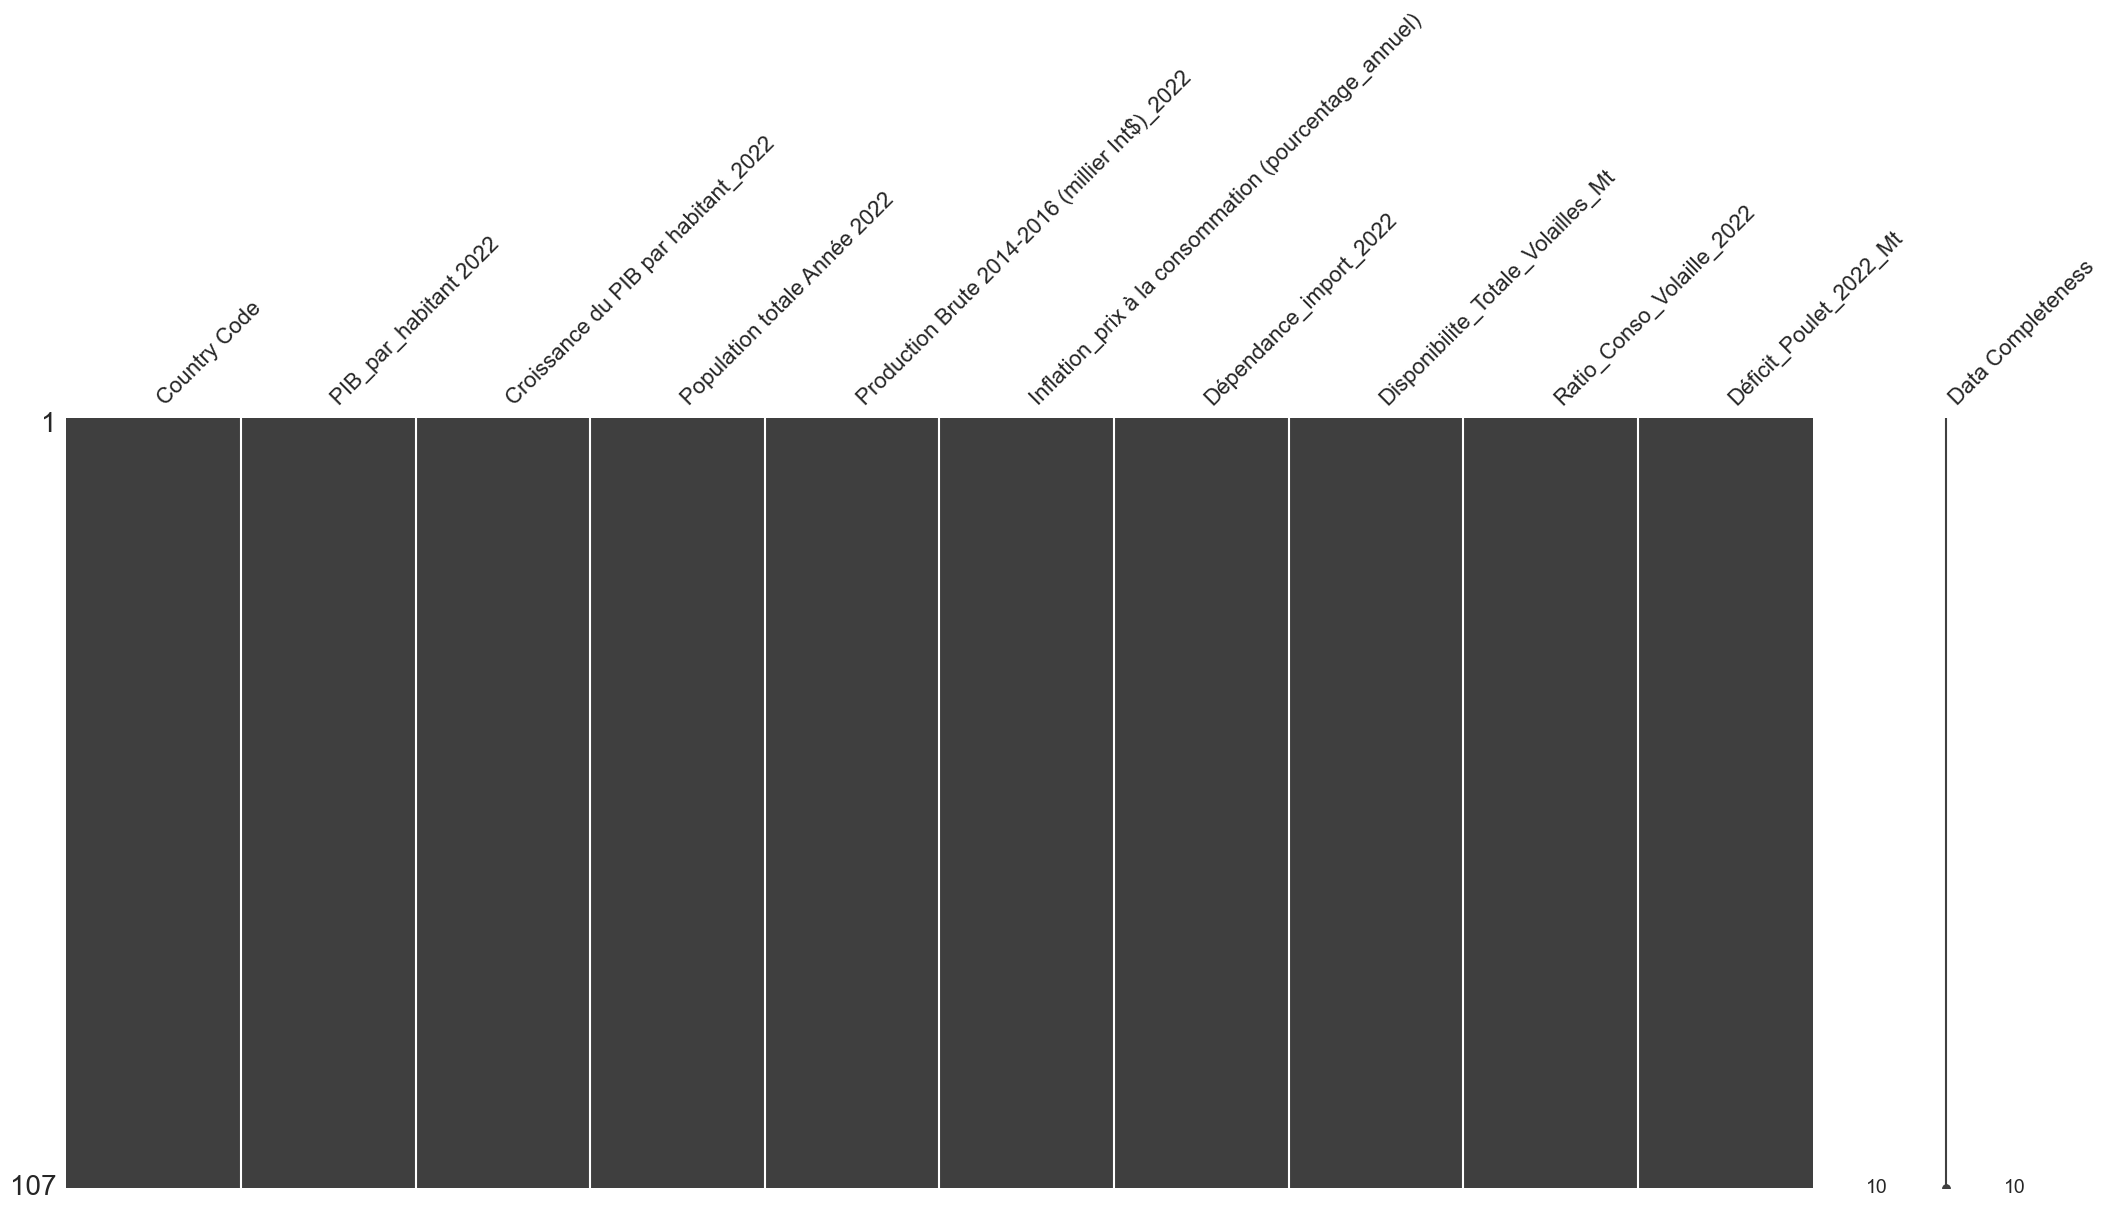

In [19]:
!pip install missingno
import missingno as msno
# Affichage des valeurs manquantes sous forme de matrice

msno.matrix(df_final,labels=True)

In [20]:
# 1. Définition du nombre total de lignes (pays)
nbre_total_lignes = len(df_final)

# 2. Définition du nombre de valeurs manquantes par variable

nbre_manquants = df_final.isnull().sum()

# 3. Calcul du pourcentage de valeurs manquantes
taux_manquants = (nbre_manquants / nbre_total_lignes) * 100

# 4. Calcul du pourcentage de complétude
pourcentage_completude = 100 - taux_manquants

# 5. Création du df pour visualiser les résultats
df_completude = pd.DataFrame({
    'Manquants (%)': taux_manquants,
    'Complétude (%)': pourcentage_completude
}).sort_values(by='Complétude (%)')
print("Taux de Complétude par Variable :")
print(df_completude.to_string())

Taux de Complétude par Variable :
                                                       Manquants (%)  Complétude (%)
Country Code                                                     0.0           100.0
PIB_par_habitant 2022                                            0.0           100.0
Croissance du PIB par habitant_2022                              0.0           100.0
Population totale Année 2022                                     0.0           100.0
Production Brute 2014-2016 (millier Int$)_2022                   0.0           100.0
Inflation_prix à la consommation (pourcentage_annuel)            0.0           100.0
Dépendance_import_2022                                           0.0           100.0
Disponibilite_Totale_Volailles_Mt                                0.0           100.0
Ratio_Conso_Volaille_2022                                        0.0           100.0
Déficit_Poulet_2022_Mt                                           0.0           100.0


### Calcul du taux de Complétude

In [21]:
SEUIL_COMPLETUDE = 80

# 1. Calcul de la complétude (%) pour chaque colonne
taux_completude = df_final.notna().mean() * 100

# 2. Sélection des colonnes à supprimer
colonnes_a_supprimer = taux_completude[taux_completude < SEUIL_COMPLETUDE].tolist()

# 3. Suppression des colonnes du DataFrame
df_final_clean = df_final.drop(columns=colonnes_a_supprimer)

# 4. Affichage
print(f"\n✅ Suppression des colonnes avec complétude < {SEUIL_COMPLETUDE}%")
if colonnes_a_supprimer:
    print(f"Colonnes supprimées : {colonnes_a_supprimer}")
else:
    print("Aucune colonne n'a été supprimée.")
    
print(f"Nombre de colonnes restantes : {len(df_final_clean.columns)}")



✅ Suppression des colonnes avec complétude < 80%
Aucune colonne n'a été supprimée.
Nombre de colonnes restantes : 10


### Affichage des statistiques

In [22]:
df_final_clean.describe()

,PIB_par_habitant 2022,Croissance du PIB par habitant_2022,Population totale Année 2022,Production Brute 2014-2016 (millier Int$)_2022,Inflation_prix à la consommation (pourcentage_annuel),Dépendance_import_2022,Disponibilite_Totale_Volailles_Mt,Ratio_Conso_Volaille_2022,Déficit_Poulet_2022_Mt
count,107.000000,107.000000,1.070000e+02,1.070000e+02,107.000000,107.000000,107.000000,107.000000,107.000000
mean,13837.143134,3.555017,5.655063e+07,1.694739e+09,13.394017,36.748146,984.205607,1.424993,-33.654206
std,21481.762262,7.572251,1.979650e+08,5.364695e+09,21.501105,38.680260,3198.356048,1.526877,613.647663
min,357.261153,-22.745681,4.670900e+04,2.000000e+03,-1.610680,0.000000,2.000000,0.073677,-4549.000000
25%,2323.960520,1.514894,2.732039e+06,1.925200e+07,5.432042,1.914701,41.500000,0.505751,1.000000
50%,5986.636949,2.889661,1.046387e+07,1.713010e+08,7.922049,19.812878,123.000000,0.942008,9.000000
75%,13037.214978,4.770585,3.408547e+07,7.347470e+08,11.219924,74.133811,482.000000,1.692886,48.000000
max,109269.520580,62.111071,1.425423e+09,3.812313e+10,171.205491,143.181818,25027.000000,8.064815,1150.000000


### Analyse univariée (Analyse descriptive des variables quantitatives)

In [23]:
def identifier_outliers_iqr(df, variable_cible):
    """
    Calcule et affiche les outliers (valeurs aberrantes) d'une variable 
    quantitative en utilisant la méthode de l'Écart Interquartile (IQR).
    
    Args:
        df (pd.DataFrame): Le DataFrame contenant les données.
        variable_cible (str): Le nom exact de la colonne à analyser.
    """
    if variable_cible not in df.columns:
        print(f"Erreur : La variable '{variable_cible}' n'existe pas dans le DataFrame.")
        return

    # 1. Calcul des quartiles
    Q1 = df[variable_cible].quantile(0.25)
    Q3 = df[variable_cible].quantile(0.75)
    IQR = Q3 - Q1

    # 2. Définition des bornes (Méthode 1.5 * IQR)
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    # 3. Filtrage du DataFrame pour afficher les outliers
    outliers = df[
        (df[variable_cible] < borne_inf) |
        (df[variable_cible] > borne_sup)
    ]
    
    # Trie des outliers (du plus grand au plus petit)
    outliers_tries = outliers.sort_values(
        by=variable_cible,
        ascending=False
    )

    print("=" * 70)
    print(f"📊 Analyse des Outliers par IQR pour : {variable_cible}")
    print("=" * 70)
    print(f"Q1 (25e percentile): {Q1:.2f}")
    print(f"Q3 (75e percentile): {Q3:.2f}")
    print(f"Écart Interquartile (IQR): {IQR:.2f}")
    print(f"Borne Inférieure (Outlier <): {borne_inf:.2f}")
    print(f"Borne Supérieure (Outlier >): {borne_sup:.2f}")
    print("-" * 70)
    
    if outliers_tries.empty:
        print(" Aucune valeur aberrante détectée par la méthode 1.5 * IQR.")
    else:
        print(f"⚠️ {len(outliers_tries)} Valeur(s) aberrante(s) détectée(s) :")
        # Affichage du Code Pays et de la valeur
        print(outliers_tries[['Country Code', variable_cible]].to_string(index=False))

In [24]:
variables_a_analyser = ['PIB_par_habitant 2022',
                        'Croissance du PIB par habitant_2022',
    'Population totale Année 2022',
    'Production Brute 2014-2016 (millier Int$)_2022',
    'Inflation_prix à la consommation (pourcentage_annuel)',
    'Dépendance_import_2022',
    'Disponibilite_Totale_Volailles_Mt','Ratio_Conso_Volaille_2022', 'Déficit_Poulet_2022_Mt'
]

for var in variables_a_analyser:
    identifier_outliers_iqr(df_final_clean, var)

📊 Analyse des Outliers par IQR pour : PIB_par_habitant 2022
Q1 (25e percentile): 2323.96
Q3 (75e percentile): 13037.21
Écart Interquartile (IQR): 10713.25
Borne Inférieure (Outlier <): -13745.92
Borne Supérieure (Outlier >): 29107.10
----------------------------------------------------------------------
⚠️ 15 Valeur(s) aberrante(s) détectée(s) :
Country Code  PIB_par_habitant 2022
         NOR          109269.520580
         CHE           94394.510680
         QAT           88701.463352
         USA           77860.911291
         ISL           75121.015228
         AUS           64997.013654
         CAN           56256.800726
         ISR           54949.621556
         ARE           49899.065298
         NZL           48760.038194
         GBR           46062.991408
         KWT           39981.769098
         SAU           38510.227621
         BHS           34957.161328
         BHR           30470.521928
📊 Analyse des Outliers par IQR pour : Croissance du PIB par habitant_2022
Q1

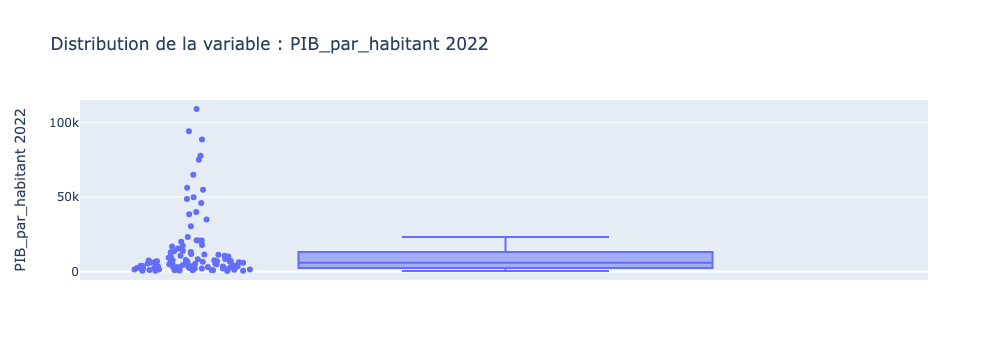

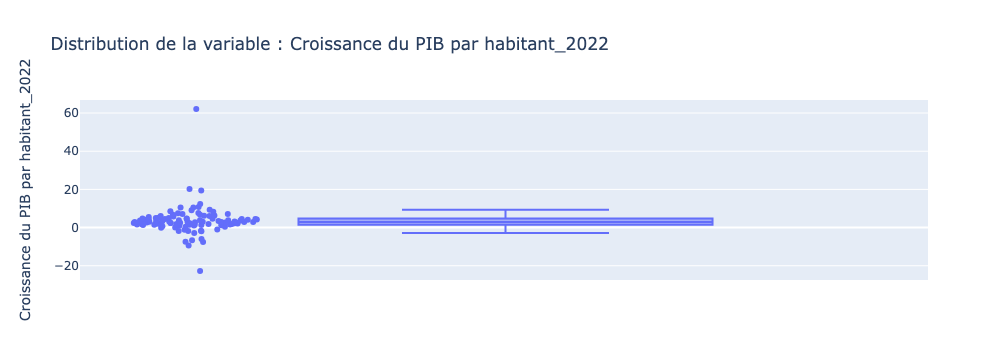

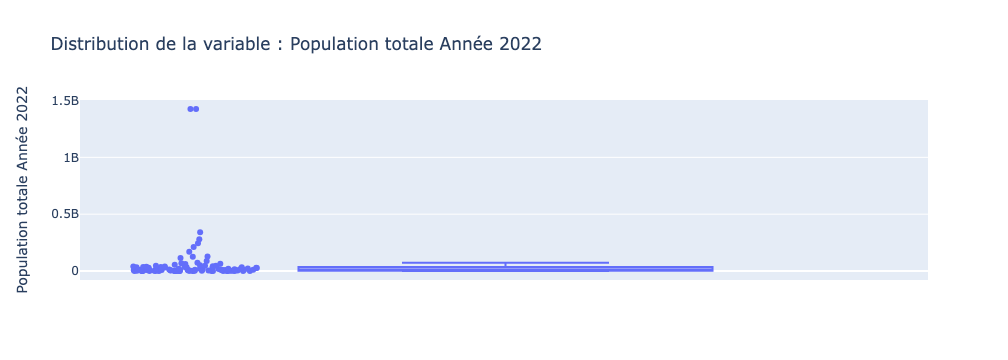

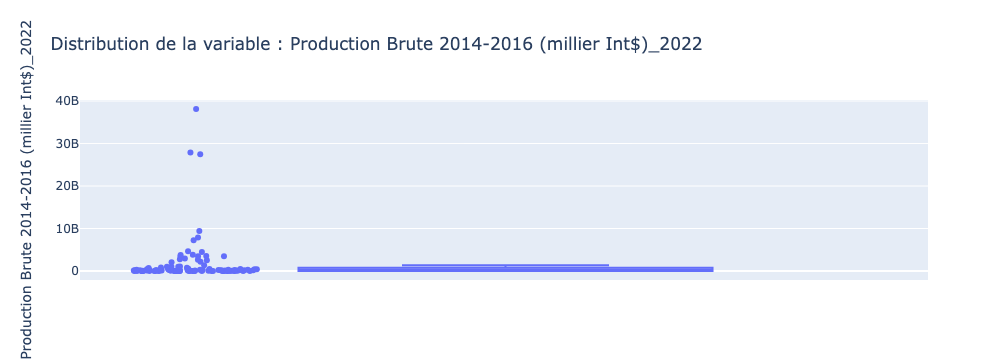

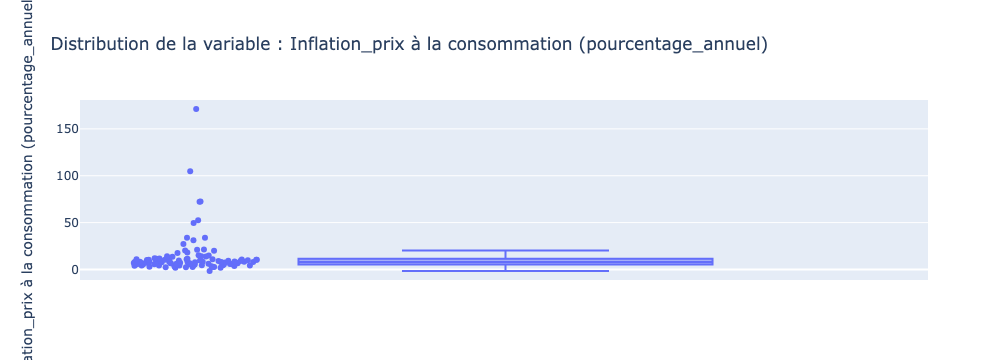

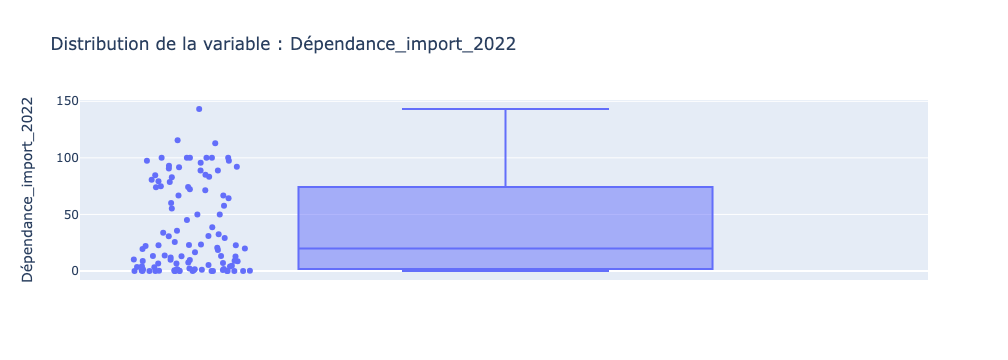

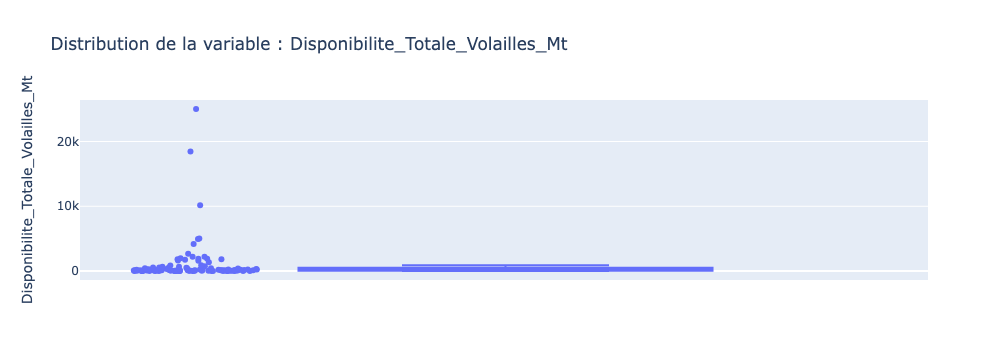

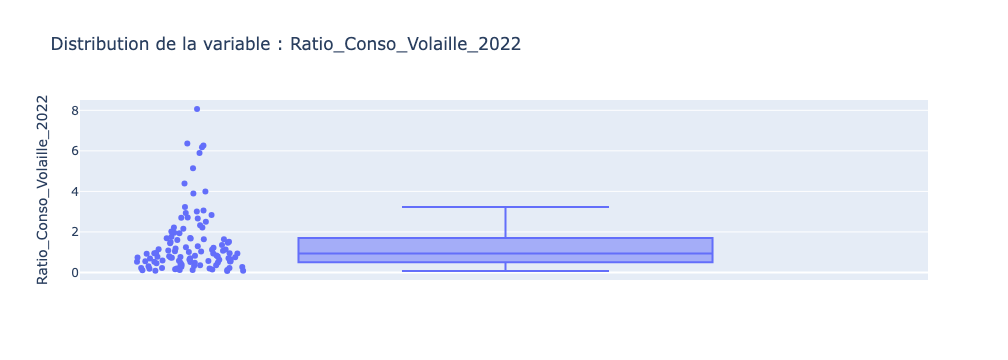

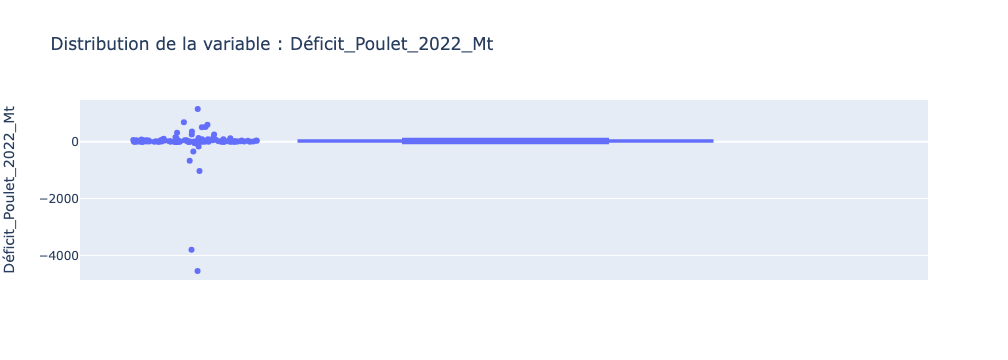

In [25]:
# Liste des variables pour lesquelles nous voulons un Box Plot
variables_a_visualiser = [
    'PIB_par_habitant 2022',
    'Croissance du PIB par habitant_2022',
    'Population totale Année 2022',
    'Production Brute 2014-2016 (millier Int$)_2022',
    'Inflation_prix à la consommation (pourcentage_annuel)',
    'Dépendance_import_2022',
    'Disponibilite_Totale_Volailles_Mt','Ratio_Conso_Volaille_2022','Déficit_Poulet_2022_Mt']


for var in variables_a_visualiser:
    # Création des BoxPlots
    fig = px.box(
        df_final_clean,
        y=var,
        points="all", # Affiche tous les points, y compris les outliers
        hover_data=["Country Code"],
        title=f"Distribution de la variable : {var}",
    )
    
    # Mise à jour de la mise en page
    fig.update_layout(
        yaxis_title=var,
        # Optionnel: Ajout d'une ligne de référence pour l'Inflation à 0%
        shapes=[] 
    )

    # Ajout de la ligne de référence à 0% uniquement pour l'inflation
    if var == 'Inflation_prix à la consommation (% annuel)':
        fig.add_shape(
            type='line',
            xref='paper', yref='y',
            x0=0, y0=0, x1=1, y1=0,
            line=dict(color='Red', width=2, dash='dash'),
        )
        
    fig.show()

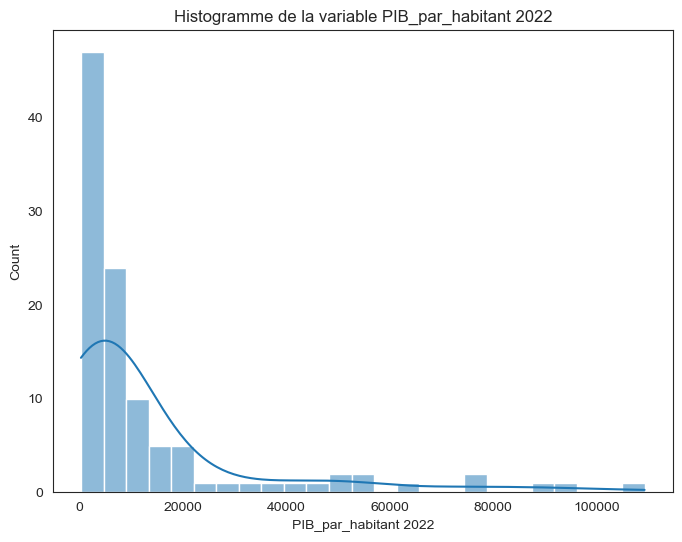

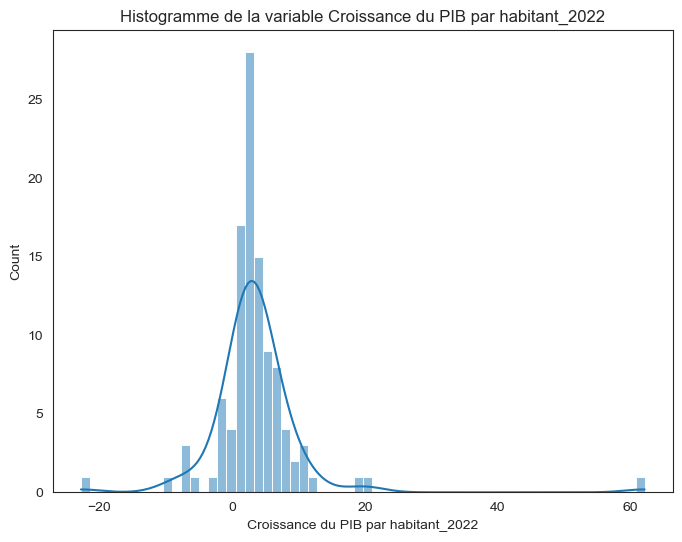

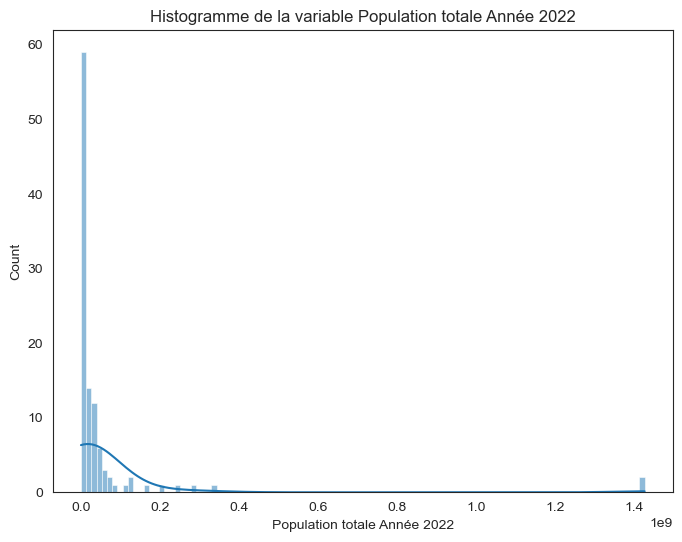

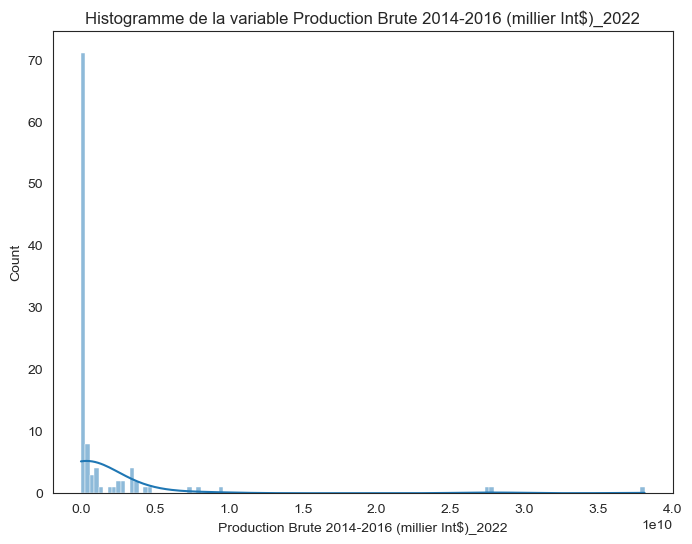

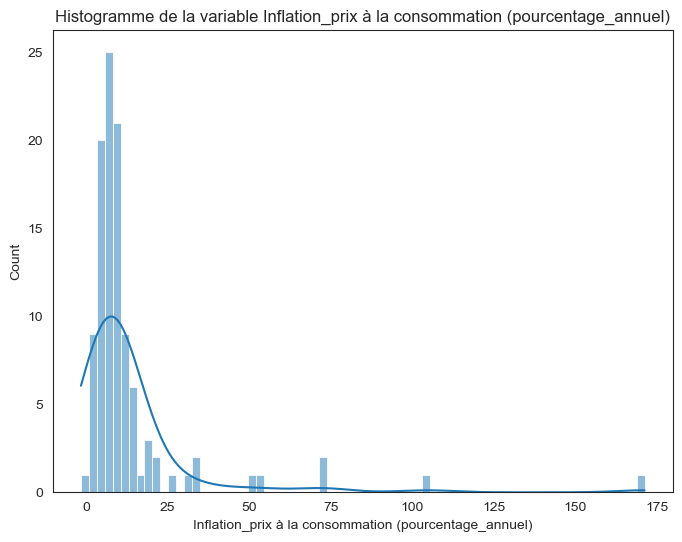

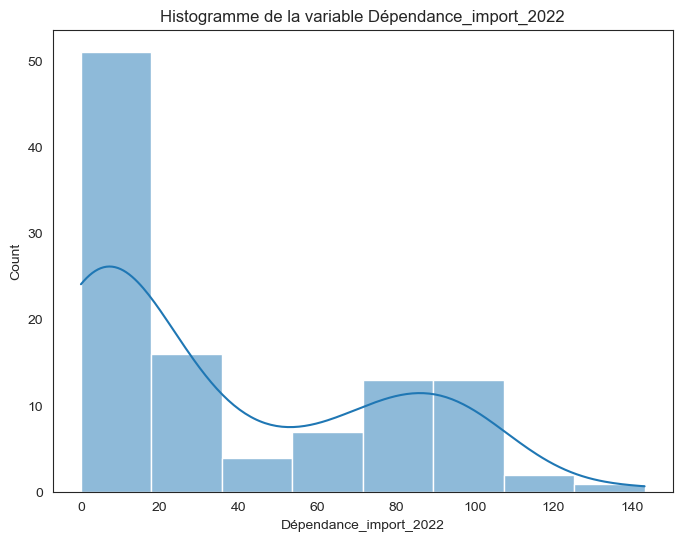

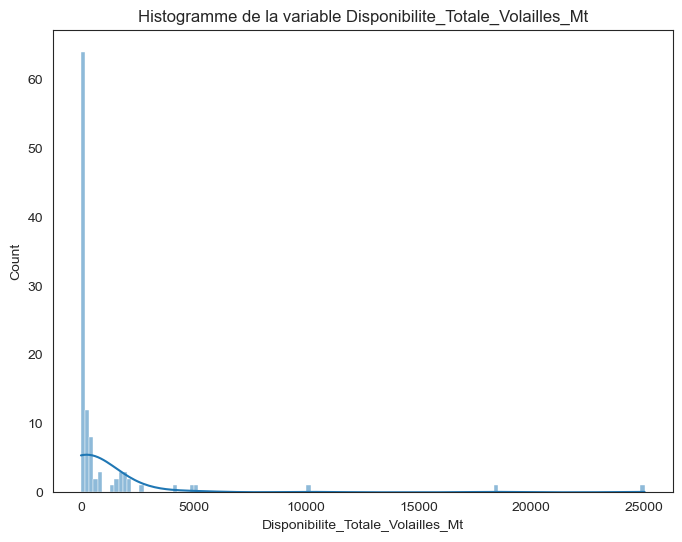

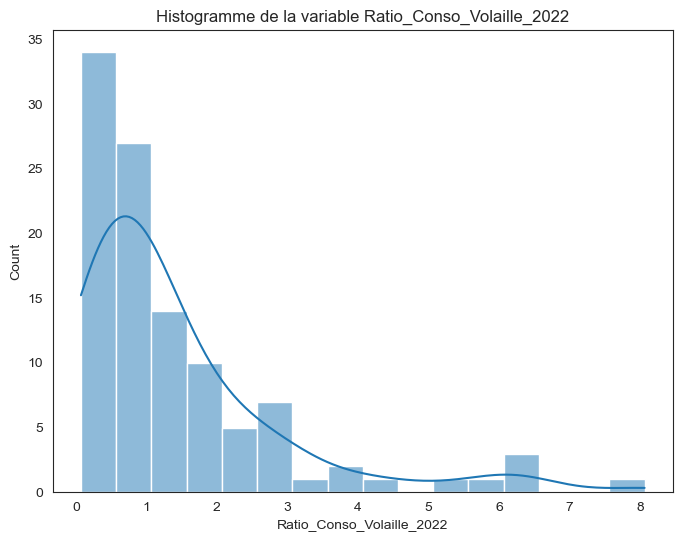

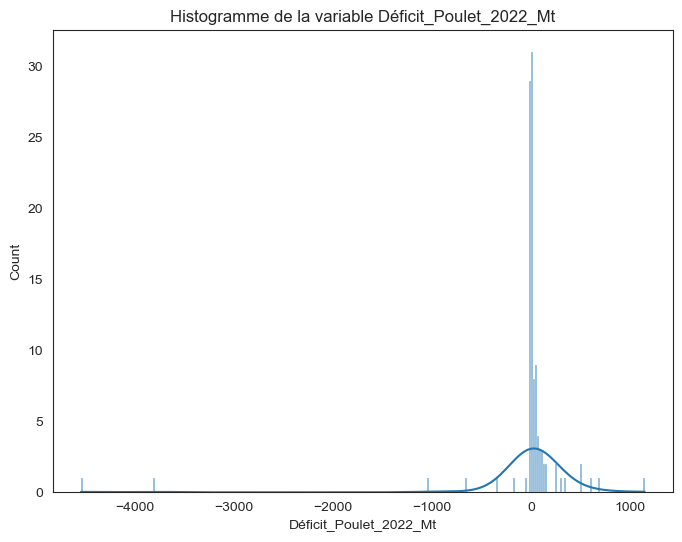

In [26]:
# Analyse de la normalité
from scipy.stats import shapiro

# Création d'un histogramme et d'un test de normalité pour chaque variable
for column in variables_a_analyser:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df_final_clean, x=column, kde=True)
    plt.title(f"Histogramme de la variable {column}")
    plt.show()

In [27]:
#test de normalité

from scipy.stats import shapiro

resultats_shapiro = []

for var in variables_a_analyser:
    
    # Test de Shapiro-Wilk
    stat, p_value = shapiro(df_final_clean[var].dropna()
)
    
    resultats_shapiro.append({
        "Variable": var,
        "Statistique W": round(stat, 3),
        "p-value": round(p_value, 4),
        "Normalité (α = 5%)": "Oui" if p_value > 0.05 else "Non"
    })

df_shapiro = pd.DataFrame(resultats_shapiro)
df_shapiro


,Variable,Statistique W,p-value,Normalité (α = 5%)
0,PIB_par_habitant 2022,0.617,0.0,Non
1,Croissance du PIB par habitant_2022,0.609,0.0,Non
2,Population totale Année 2022,0.263,0.0,Non
3,Production Brute 2014-2016 (millier Int$)_2022,0.329,0.0,Non
4,Inflation_prix à la consommation (pourcentage_...,0.442,0.0,Non
5,Dépendance_import_2022,0.839,0.0,Non
6,Disponibilite_Totale_Volailles_Mt,0.308,0.0,Non
7,Ratio_Conso_Volaille_2022,0.750,0.0,Non
8,Déficit_Poulet_2022_Mt,0.314,0.0,Non


### Analyse Bivariée

#### Analyse graphique

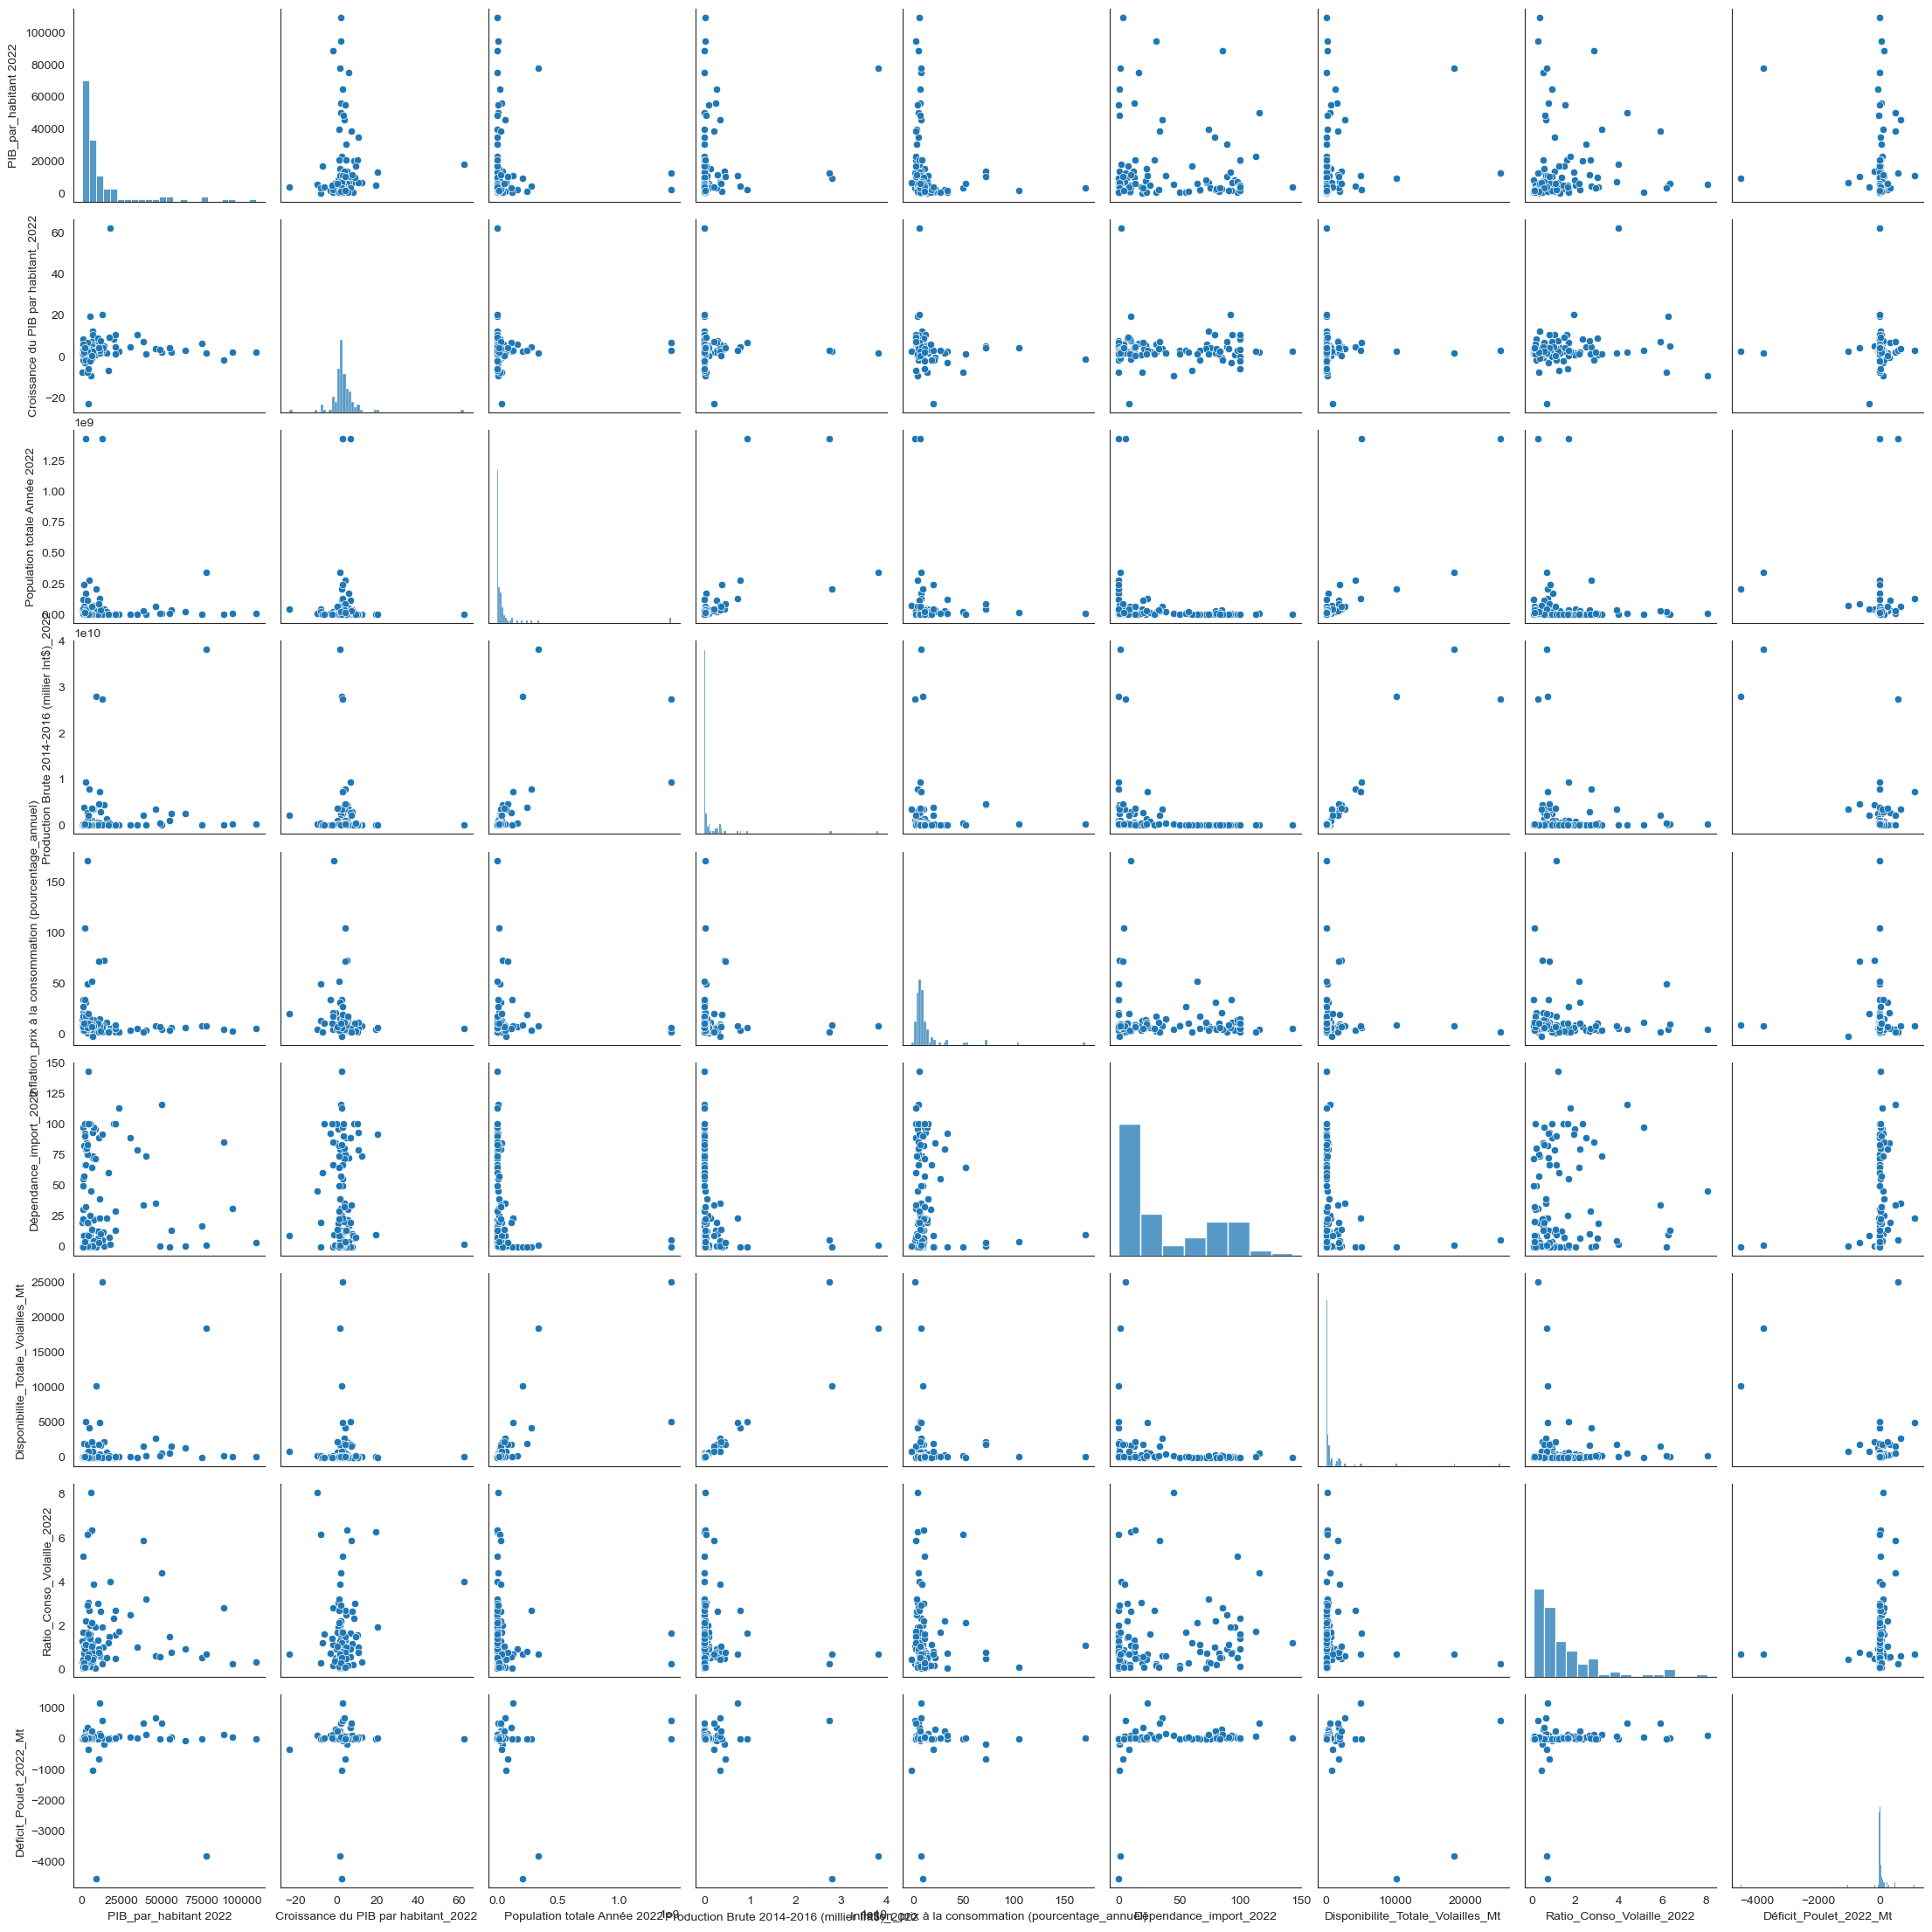

In [28]:
# Relation entre deux variables quantitatives

sns.pairplot(df_final_clean)

| **Variable**                               | **Type de distribution**                 | **Caractéristique clé**                                                                              |
| ------------------------------------------ | ---------------------------------------- | ---------------------------------------------------------------------------------------------------- |
| **PIB par habitant 2022**                  | Très asymétrique positive (skewed right) | Forte concentration des pays à faible PIB ; présence de quelques outliers très élevés (pays riches). |
| **Croissance du PIB par habitant 2022**    | Relativement centrée                     | Concentration autour de zéro ; dispersion entre croissance et récession.                             |
| **Population totale 2022**                 | Très asymétrique positive (skewed right) | Majorité de pays faiblement peuplés ; quelques pays très peuplés dominants.                          |
| **Production brute 2014–2016**             | Très asymétrique positive (skewed right) | Forte concentration de la production dans peu de pays.                                               |
| **Inflation (prix à la consommation)**     | Asymétrique positive                     | Inflation faible pour la majorité des pays ; queue à droite pour fortes inflations.                  |
| **Dépendance aux importations 2022**       | Concentration à gauche                   | Majorité des pays faiblement dépendants (≈ 0–20 %).                                                  |
| **Disponibilité totale de volailles (Mt)** | Très asymétrique positive (skewed right) | Très forte concentration ; présence d’outliers extrêmes.                                             |
| **Ratio de consommation de volaille 2022** | Multimodale / bimodale                   | Un groupe proche de l’autosuffisance et un autre fortement dépendant.                                |


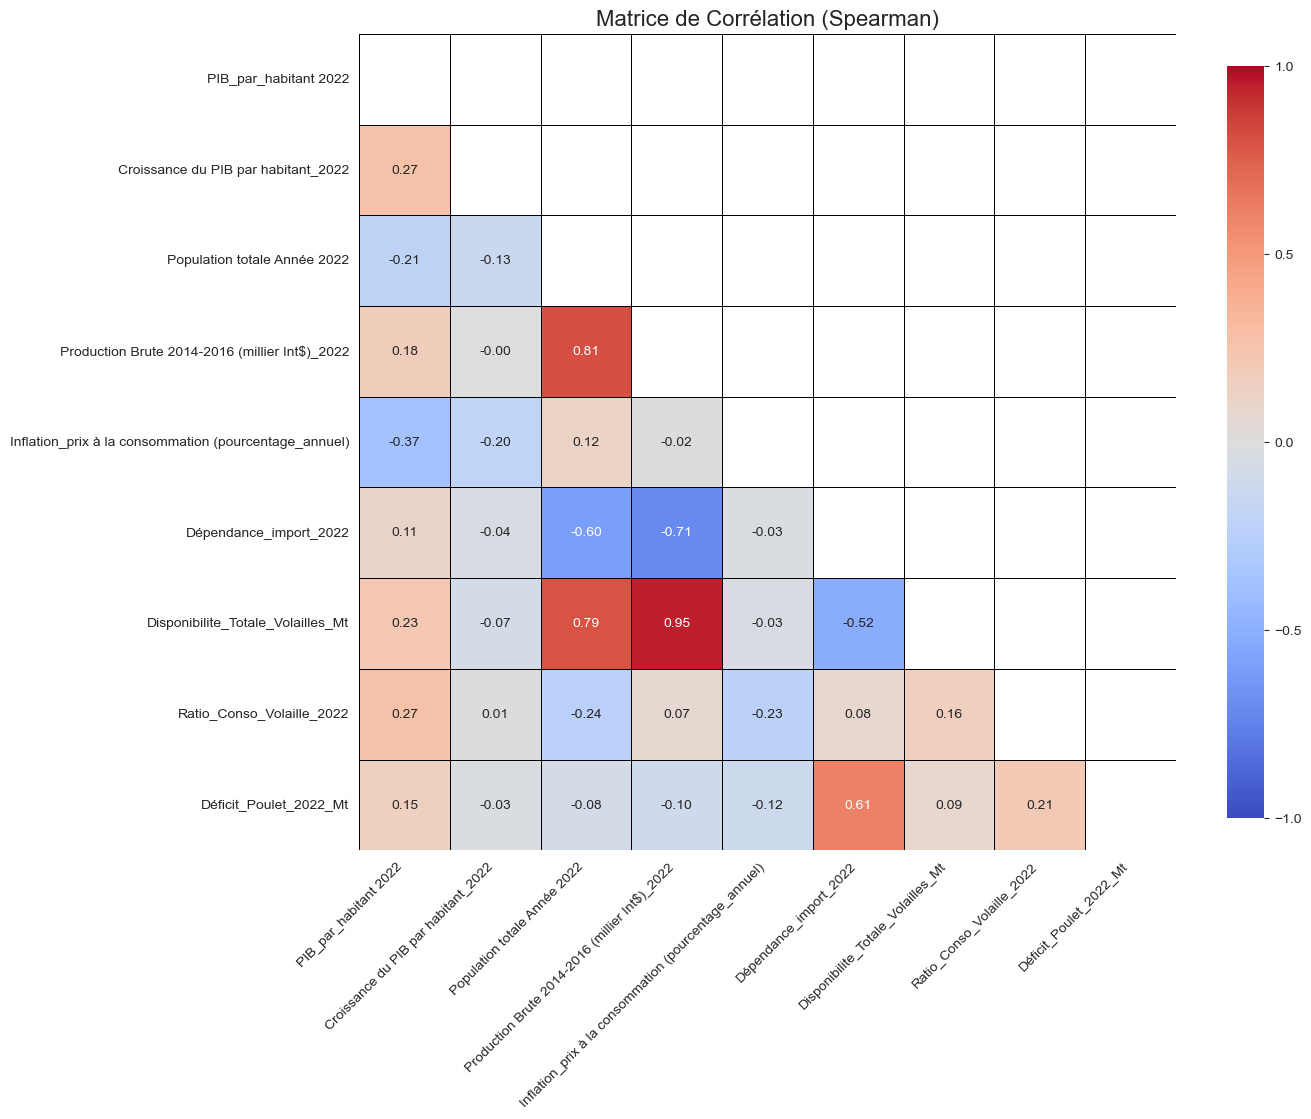

In [29]:
# Tableau de corélation et la heatmap (corrélation de Spearman)
#robuste aux outliers
#adaptée aux distributions asymétriques
#mesure les relations monotones
#parfaite pour une analyse exploratoire multi-pays

corr = df_final_clean[variables_a_analyser].corr(method='spearman')

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='black',
    cbar_kws={'shrink': 0.8, 'ticks': [-1, -0.5, 0, 0.5, 1]},
    annot_kws={"size": 10}
)

plt.title("Matrice de Corrélation (Spearman)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('Matrice de Corrélation_Spearman.png', dpi=300, bbox_inches='tight')
plt.show()
